# Imputation, Model Processing, Model Creation
This file processes the upstream processed data set (proc_data) for the purposes of model creation

In [1]:
from __future__ import annotations
import argparse
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
%matplotlib inline
from math import pi
import itertools

# mixed-effects logistic regression on sub_pruned split (binary naccudsd_bin)
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# temporal clustering (to learn states + transitions) - best fit: hidden markovv models ...
from hmmlearn.hmm import MultinomialHMM


In [3]:
m = pd.read_excel("variable_mapping.xlsx")

# brings run_pipeline() into scope and runs no extra code (since you cleaned it)
%run -i data_proc.ipynb

# call with your single flag
_, proc_data, _ = run_pipeline(drop_visit_year=False)

C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3030577239.py:27: DtypeWarning: Columns (20,22,24,26,28,41,44,46,48,51,61,63,65,67,69,71,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,134,156,165,176,179,189,217,220,222,224,226,228,230,232,234,236,238,240,242,244,246,248,250,252,254,256,258,260,262,264,266,268,270,272,382,397,399,401,419,421,423,432,445,454,494,574,605,613,638,674,690,704,707,710,715,727,738,744,746,804,809,810,811,812,820,831,833,835,837,843,904,959,960,961,969,970,971,972,982,1004,1007,1010) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv(r"C:\Users\miked\Desktop2\RIT ISTE Data Mining\project\investigator_nacc70.csv")


removed 281 composite columns
initial shape: (204031, 743)
after keep_v3_plus: (100120, 743)
after drop_not_in_v3: (100120, 592)
after drop_text_x_columns: (100120, 558)
after clean_placeholders: (100120, 558)
after fill_moca: (100120, 558)
after clean_npiq_severity: (100120, 558)
backfill_a5_from_mapping_df: filled 1321121 values across 39 columns.
 top fills: TOBAC30:35761, TOBAC100:35761, SMOKYRS:35761, PACKSPER:35761, QUITSMOK:35761, ALCOCCAS:35761, CVHATT:35761, CVOTHR:35761, CBSTROKE:35761, STROKMUL:35761
after backfill_a5_from_mapping_df: (100120, 558)
after apply_score_nonres_bounds: (100120, 805)
after flag_admin_and_missing: (100120, 1354)
after fix_dtypes: (100120, 1354)
after combine_img_fields: (100120, 1353)
after add_visit_features: (100120, 1356)
after drop_visit_parts_after_visit_date: (100120, 1354)
Final Shape: (100120, 1354)


In [5]:
def impute_age(df: pd.DataFrame,
               id_col: str = "NACCID",
               date_col: str = "visit_date",
               age_col: str = "NACCAGE",
               baseline_col: str = "NACCAGEB") -> pd.DataFrame:
    """
    Step 1: Fill ONLY missing NACCAGE using nearest visit within subject.
    Step 2: For any remaining missing, fill from NACCAGEB + years since first visit.
    Does not overwrite existing ages.
    """
    out = df.copy()

    # ensure datetime and stable sort
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.sort_values([id_col, date_col], kind="mergesort")

    # ---------- Step 1: nearest-visit fill ----------
    g = out.groupby(id_col, sort=False)

    age_ff  = g[age_col].ffill()
    date_ff = g[date_col].ffill()

    age_bf  = g[age_col].bfill()
    date_bf = g[date_col].bfill()

    secs_per_year = 60*60*24*365.25
    # forward candidate = last_known_age + (cur_date - last_known_date)
    dt_minus_ff = (out[date_col].astype("int64") - date_ff.astype("int64")) / 1e9
    cand_ff = age_ff + (dt_minus_ff / secs_per_year)

    # backward candidate = next_known_age - (next_known_date - cur_date)
    bf_minus_dt = (date_bf.astype("int64") - out[date_col].astype("int64")) / 1e9
    cand_bf = age_bf - (bf_minus_dt / secs_per_year)

    gap_ff = (out[date_col] - date_ff).dt.days.abs()
    gap_bf = (date_bf - out[date_col]).dt.days.abs()

    has_ff = age_ff.notna()
    has_bf = age_bf.notna()

    nearest = pd.Series(np.nan, index=out.index, dtype=float)
    both = has_ff & has_bf
    pick_ff = both & (gap_ff <= gap_bf)
    pick_bf = both & (gap_bf <  gap_ff)
    nearest.loc[pick_ff] = cand_ff.loc[pick_ff]
    nearest.loc[pick_bf] = cand_bf.loc[pick_bf]
    nearest.loc[has_ff & ~has_bf] = cand_ff.loc[has_ff & ~has_bf]
    nearest.loc[has_bf & ~has_ff] = cand_bf.loc[has_bf & ~has_ff]

    need1 = out[age_col].isna()
    out.loc[need1, age_col] = nearest.loc[need1]

    # ---------- Step 2: baseline (NACCAGEB) + years since first visit ----------
    remaining = out[age_col].isna()
    if remaining.any() and baseline_col in out.columns:
        # per-subject first visit date
        first_date = g[date_col].transform("min")

        # per-subject baseline age (first non-null baseline_col)
        base_age = (
            out.loc[out[baseline_col].notna(), [id_col, baseline_col]]
               .drop_duplicates(subset=[id_col])
               .set_index(id_col)[baseline_col]
        )

        # map baseline into rows
        base_mapped = out[id_col].map(base_age)
        yrs_since_first = (out[date_col] - first_date).dt.total_seconds() / secs_per_year

        need2 = remaining & base_mapped.notna() & out[date_col].notna()
        out.loc[need2, age_col] = base_mapped.loc[need2] + yrs_since_first.loc[need2]

    # optional: report
    print("impute_age: remaining missing NACCAGE =", int(out[age_col].isna().sum()))
    return out



def impute_a1_baseline(df: pd.DataFrame,
                       m: pd.DataFrame,
                       *,
                       id_col: str = "NACCID",
                       date_col: str = "visit_date",
                       packet_col: str = "PACKET",
                       donor_packets: tuple[str, ...] = ("IT", "I"),
                       target_packets: tuple[str, ...] = ("F","FT","T"),
                       fill_missing_only: bool = True,
                       verbose: bool = True) -> pd.DataFrame:
    df = df.copy()
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    form_col = next((c for c in ["form","Form","FORM"] if c in m.columns), None)
    if form_col is None or "Variable" not in m.columns:
        if verbose:
            print("impute_a1_baseline: mapping missing form/Variable; skipping.")
        return df

    a1_vars = [c for c in m.loc[m[form_col].astype(str).str.lower()=="a1","Variable"].dropna() if c in df.columns]
    if not a1_vars:
        if verbose:
            print("impute_a1_baseline: no A1 vars present; nothing to do.")
        return df

    pkt = df.get(packet_col, pd.Series(index=df.index, dtype=object)).astype(str).str.upper()
    donor_set = {p.upper() for p in donor_packets}
    target_set = {p.upper() for p in target_packets}
    pref = {p:i for i,p in enumerate(donor_packets)}
    df["_pkt_order"] = pkt.map(pref)

    donors = df.loc[pkt.isin(donor_set), [id_col, date_col, "_pkt_order"] + a1_vars].sort_values([id_col,"_pkt_order",date_col])

    base = {}
    for v in a1_vars:
        s = donors.loc[donors[v].notna(), [id_col, v]].groupby(id_col, as_index=True)[v].first()
        base[v] = s

    is_target = pkt.isin(target_set)
    filled = 0
    for v in a1_vars:
        was_cat = isinstance(df[v].dtype, CategoricalDtype)
        bm = df[id_col].map(base[v])
        need = is_target & bm.notna() & (df[v].isna() if fill_missing_only else True)
        if need.any():
            df.loc[need, v] = bm.loc[need]
            filled += int(need.sum())
        if was_cat:
            df[v] = df[v].astype("category")
            try:
                df[v] = df[v].cat.remove_unused_categories()
            except Exception:
                pass

    df.drop(columns=["_pkt_order"], inplace=True, errors="ignore")
    if verbose:
        mode = "fill-missing" if fill_missing_only else "overwrite-all"
        print(f"impute_a1_baseline: updated {filled} cells across {len(a1_vars)} vars ({mode}).")
    return df

# def impute_cdr(df, id_col, cdr_col):
#     """
#     Impute CDR using participant-level mode of prior values.
#     If no prior values exist, use next non-missing forward value.
#     If no values at all, leave missing.
#     """
#     out = df.copy()
    
#     # Loop by participant
#     for pid, g in out.groupby(id_col, sort=False):
#         idx = g.index
        
#         # the series we will fill
#         c = g[cdr_col].copy()
        
#         # 1. Fill using mode of ALL prior values
#         for i in range(len(c)):
#             if pd.isna(c.iloc[i]):
#                 prior = c.iloc[:i].dropna()
#                 if len(prior) > 0:
#                     c.iloc[i] = prior.mode().iloc[0]
        
#         # 2. If still missing, use next non-missing forward value
#         for i in reversed(range(len(c))):
#             if pd.isna(c.iloc[i]):
#                 after = c.iloc[i+1:].dropna()
#                 if len(after) > 0:
#                     c.iloc[i] = after.iloc[0]
        
#         out.loc[idx, cdr_col] = c
    
#     return out

def impute_cdr(df: pd.DataFrame, id_col: str, cdr_col: str) -> pd.DataFrame:
    """
    Faster CDR imputation per subject:
      1) Sort by id + visit_date (if available).
      2) Within each subject, forward-fill CDR values.
      3) Then backward-fill remaining NaNs within each subject.

    This approximates your original behavior (carrying prior values forward,
    and using later values only when there are no prior ones) but uses
    vectorized ffill/bfill instead of Python loops.
    """
    out = df.copy()

    # make sure visits are in time order within subject
    if "visit_date" in out.columns:
        out["visit_date"] = pd.to_datetime(out["visit_date"], errors="coerce")
        out = out.sort_values([id_col, "visit_date"]).reset_index(drop=True)

    s = out[cdr_col]

    # forward-fill within subject
    filled = s.groupby(out[id_col], sort=False).ffill()
    # backward-fill remaining missing within subject
    filled = filled.groupby(out[id_col], sort=False).bfill()

    out[cdr_col] = filled
    return out

def impute_cat(df: pd.DataFrame,
               id_col: str = "NACCID",
               exclude: set[str] | None = None) -> pd.DataFrame:
    df = df.copy()
    exclude = exclude or set()
    obj_or_cat = [c for c in df.columns
                  if c not in exclude and (df[c].dtype=="object" or isinstance(df[c].dtype, CategoricalDtype) or pd.api.types.is_string_dtype(df[c]))]
    if not obj_or_cat:
        return df
    if "visit_date" in df.columns:
        df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
        df = df.sort_values([id_col, "visit_date"]).reset_index(drop=True)
    for c in obj_or_cat:
        grp = df.groupby(id_col, sort=False)[c]
        df[c] = grp.ffill().bfill()
        if isinstance(df[c].dtype, CategoricalDtype):
            df[c] = df[c].astype("category")
    return df


def impute_num(df: pd.DataFrame,
               id_col: str = "NACCID",
               keep_flags_prefix: str = "invalid_",
               skip_cols: set[str] | None = None) -> pd.DataFrame:
    """
    fast numeric imputation:
      - per-subject mean (using only rows where invalid_flag==0 when present)
      - then global mean fallback
      - fills only where NaN; keeps invalid_* flags as int
    """
    out = df.copy()
    skip_cols = skip_cols or set()

    # only numeric cols with any NaNs
    num_cols = [c for c in out.columns
                if c not in skip_cols and pd.api.types.is_numeric_dtype(out[c])]
    need_cols = [c for c in num_cols if out[c].isna().any()]

    # preserve/normalize flags
    flag_cols = []
    for c in num_cols:
        if c.startswith(keep_flags_prefix):
            out[c] = out[c].fillna(0).astype("int64")
            flag_cols.append(c)

    # impute value columns
    val_cols = [c for c in need_cols if not c.startswith(keep_flags_prefix)]
    gid = out[id_col]

    for c in val_cols:
        f = f"{keep_flags_prefix}{c}"
        s = out[c]

        if f in out.columns:
            # per-subject mean using valid rows only
            valid_s = s.where(out[f].eq(0))
            subj_mean = valid_s.groupby(gid, sort=False).transform("mean")
        else:
            subj_mean = s.groupby(gid, sort=False).transform("mean")

        # fill with subject mean, then global mean
        s = s.fillna(subj_mean)
        if s.isna().any():
            s = s.fillna(s.mean())

        out[c] = s

    return out


def finalize_invalid_flags(df: pd.DataFrame,
                           prefix: str = "invalid_",
                           add_missing_flags: bool = True,
                           verbose: bool = True) -> pd.DataFrame:
    df = df.copy()
    flag_cols = [c for c in df.columns if c.startswith(prefix)]
    if not flag_cols:
        if verbose:
            print(f"finalize_invalid_flags: no columns found with prefix '{prefix}'.")
        return df
    if add_missing_flags:
        for c in flag_cols:
            df[f"{c}_na"] = df[c].isna().astype("int64")
    for c in flag_cols:
        df[c] = df[c].fillna(0).astype("int64")
    if verbose:
        print(f"finalize_invalid_flags: processed {len(flag_cols)} flag columns (add_missing_flags={add_missing_flags}).")
    return df

def one_hot_small_cats(df: pd.DataFrame,
                       cat_cols: list[str],
                       min_freq: int = 20) -> tuple[pd.DataFrame, dict[str, list[str]]]:
    df = df.copy()
    mapping: dict[str, list[str]] = {}
    parts = []
    for c in cat_cols:
        s = df[c].astype("object")
        vc = s.value_counts()
        keep_vals = set(vc[vc >= min_freq].index)
        oh = pd.get_dummies(s.where(s.isin(keep_vals), "__other__"), prefix=c, dummy_na=False)
        mapping[c] = oh.columns.tolist()
        parts.append(oh)
    if parts:
        df = pd.concat([df.drop(columns=cat_cols, errors="ignore")] + parts, axis=1)
    return df, mapping

# --------------------------------------------
# correlation pruning helpers
# --------------------------------------------
def _vars_by_forms(m: pd.DataFrame, forms: set[str], df_cols: set[str]) -> list[str]:
    if "form" not in m.columns or "Variable" not in m.columns:
        return []
    f = m["form"].astype(str).str.lower()
    v = m["Variable"].astype(str)
    want = {s.lower() for s in forms}
    return [x for x in v[f.isin(want)].tolist() if x in df_cols]


def _demean_by_id(df: pd.DataFrame, cols: list[str], id_col: str) -> pd.DataFrame:
    tmp = pd.concat([df[[id_col]], df[cols]], axis=1)
    parts = []
    for _, g in tmp.groupby(id_col, sort=False):
        parts.append(g[cols] - g[cols].mean(axis=0))
    return pd.concat(parts, axis=0)


def _choose_drop_by_y(df_sub: pd.DataFrame, a: str, b: str, y_col: str) -> str:
    mask_a = df_sub[a].notna() & df_sub[y_col].notna()
    ra = df_sub.loc[mask_a, [a, y_col]].corr().iloc[0, 1] if mask_a.any() else np.nan
    mask_b = df_sub[b].notna() & df_sub[y_col].notna()
    rb = df_sub.loc[mask_b, [b, y_col]].corr().iloc[0, 1] if mask_b.any() else np.nan
    ra = np.abs(ra) if pd.notna(ra) else np.nan
    rb = np.abs(rb) if pd.notna(rb) else np.nan
    if pd.isna(ra) and pd.isna(rb):
        return min(a, b)
    if pd.isna(ra):
        return a
    if pd.isna(rb):
        return b
    return a if ra < rb else b

def _drop_corr_domain(df: pd.DataFrame,
                      m: pd.DataFrame,
                      forms: set[str],
                      y_col: str = "naccudsd_bin",
                      id_col: str = "NACCID",
                      thr: float = 0.80) -> tuple[pd.DataFrame, list[str]]:
    df = df.copy()
    if y_col not in df.columns or id_col not in df.columns:
        return df, []
    cand = _vars_by_forms(m, forms, set(df.columns))
    cand = [c for c in cand if pd.api.types.is_numeric_dtype(df[c]) and df[c].var(skipna=True) > 0]
    if len(cand) < 2:
        return df, []
    Z = _demean_by_id(df, cand, id_col)
    if Z.shape[1] < 2:
        return df, []
    corr = Z.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    sub = df[[y_col] + cand].dropna(subset=[y_col]).copy()
    to_drop = set()
    for col in upper.columns:
        if col in to_drop:
            continue
        highs = [c2 for c2, v in upper[col].dropna().items() if v > thr and c2 not in to_drop]
        for c2 in highs:
            cols_needed = [y_col, col, c2]
            sub_pair = sub[cols_needed].dropna()
            if sub_pair.shape[0] == 0:
                to_drop.add(min(col, c2))
                continue
            d = _choose_drop_by_y(sub_pair, col, c2, y_col)
            to_drop.add(d)
    df_out = df.drop(columns=list(to_drop), errors="ignore").copy()
    return df_out, sorted(to_drop)

def drop_corr_neuropsych(df, m, y_col="naccudsd_bin", id_col="NACCID", thr=0.80):
    neuro_forms = {"c1", "ivp_c2", "c2", "c2t", "b4"}
    return _drop_corr_domain(df, m, neuro_forms, y_col=y_col, id_col=id_col, thr=thr)

def drop_corr_functional(df, m, y_col="naccudsd_bin", id_col="NACCID", thr=0.80):
    func_forms = {"b5", "b7"}
    return _drop_corr_domain(df, m, func_forms, y_col=y_col, id_col=id_col, thr=thr)

def drop_corr_notfunneuro(df, m, y_col="naccudsd_bin", id_col="NACCID", thr=0.80, exclude_forms: set[str] | None = None):
    neuro = {"c1", "ivp_c2", "c2", "c2t", "b4"}
    func = {"b5", "b7"}
    ex = {s.lower() for s in (exclude_forms or set())}
    base_ex = neuro | func | ex
    if "form" not in m.columns:
        return df.copy(), []
    all_forms = set(m["form"].dropna().astype(str).str.lower().unique().tolist())
    other_forms = {f for f in all_forms if f not in base_ex}
    if not other_forms:
        return df.copy(), []
    return _drop_corr_domain(df, m, other_forms, y_col=y_col, id_col=id_col, thr=thr)


def drop_quasi_const_hier(df, id_col="NACCID", y_col="naccudsd_bin", thr=0.01):
    drop = []
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_categorical_dtype(df[c]):
            continue
        subj_const = (
            df.groupby(id_col)[c]
              .nunique(dropna=True)
              .eq(1)
        ).mean()
        if subj_const < 1.0 - thr:
            continue
        base = df.groupby(id_col)[c].first()
        if base.nunique(dropna=True) > 1:
            continue
        if y_col in df.columns:
            group_nu = df.groupby(y_col)[c].nunique(dropna=True)
            if (group_nu > 1).any():
                continue
        drop.append(c)
    return df.drop(columns=drop, errors="ignore"), drop
    

def drop_leaky(df: pd.DataFrame) -> pd.DataFrame:
    """Remove diagnosis-related columns that would leak target information."""
    leaky = ["NORMCOG", "DEMENTED", "IMPNOMCI", "NACCPPA", "DECCLCOG", "NACCNORM", "COGSTAT",]
    df = df.drop(columns=[c for c in leaky if c in df.columns], errors="ignore")
    return df


def drop_zero_invalid_flags(df: pd.DataFrame, prefix: str = "invalid_") -> pd.DataFrame:
    """
    Drop any flag columns (default prefix 'invalid_') that are all 0 or NaN.
    """
    invalid_cols = [c for c in df.columns if c.startswith(prefix)]
    drop_cols = [
        c for c in invalid_cols
        if df[c].fillna(0).eq(0).all()
    ]

    if drop_cols:
        df = df.drop(columns=drop_cols)
        print(f"Removed {len(drop_cols)} all-zero invalid flags.")
    else:
        print("No all-zero invalid flags found.")

    return df
    
def pick_features_for_model(df: pd.DataFrame,
                            exclude: set[str] | None = None,
                            min_nonmissing: float = 0.70) -> list[str]:
    exclude = exclude or set()
    miss = 1.0 - df.notna().mean()
    keep = miss[miss <= (1.0 - min_nonmissing)].index.tolist()
    keep = [c for c in keep if c not in exclude]
    return sorted(keep)


def drop_sparse(df: pd.DataFrame, max_missing=0.30) -> pd.DataFrame:
    """Drop columns with more than max_missing fraction missing data."""
    miss_frac = 1.0 - df.notna().mean()
    drop_cols = miss_frac[miss_frac > max_missing].index.tolist()
    if drop_cols:
        df = df.drop(columns=drop_cols)
    return df


def corr_prune_pipeline(df: pd.DataFrame, m: pd.DataFrame,
                        *, y_col: str = "naccudsd_bin", id_col: str = "NACCID",
                        thr: float = 0.80, exclude_forms: set[str] | None = None):
    dropped_by: dict[str, list[str]] = {}
    df1, d1 = drop_corr_neuropsych(df, m, y_col=y_col, id_col=id_col, thr=thr)
    dropped_by["neuropsych"] = d1
    df2, d2 = drop_corr_functional(df1, m, y_col=y_col, id_col=id_col, thr=thr)
    dropped_by["functional"] = d2
    df3, d3 = drop_corr_notfunneuro(df2, m, y_col=y_col, id_col=id_col, thr=thr, exclude_forms=exclude_forms)
    dropped_by["notfunneuro"] = d3
    dropped_all = []
    for key in ["neuropsych", "functional", "notfunneuro"]:
        for c in dropped_by.get(key, []):
            if c not in dropped_all:
                dropped_all.append(c)
    return df3, dropped_all, dropped_by

def pick_continuous_cols(df: pd.DataFrame,
                         candidate_cols: list[str]) -> list[str]:
    """
    Pick 'continuous-ish' numeric columns for scaling:
      - must be numeric
      - skip obvious dummies / small integer codes (<=5 unique values
        all in {0,1,2,3,4})
      - skip invalid_* flags and *_na indicators
    """
    out: list[str] = []
    for c in candidate_cols:
        # skip flags / obvious indicators
        if c.startswith("invalid_") or c.endswith("_na"):
            continue

        s = df[c]
        if not pd.api.types.is_numeric_dtype(s):
            continue

        s = s.dropna()
        if s.empty:
            continue

        # tiny cardinality + small ints -> treat as categorical / dummy
        u = s.unique()
        if len(u) <= 5:
            vals = set(pd.unique(s))
            if vals.issubset({0, 1, 2, 3, 4}):
                continue

        out.append(c)

    return out


## imputation + modeling data preprocessing (sequential run)

In [7]:
# assumes: proc_data (from cleaning file) and mapping file m already loaded

impute_df = proc_data.copy()

# 1) impute age
impute_df = impute_age(
    impute_df,
    id_col="NACCID",
    date_col="visit_date",
    age_col="NACCAGE",
    baseline_col="NACCAGEB"
)

# drop baseline age once used
impute_df.drop(columns=["NACCAGEB"], inplace=True, errors="ignore")      



impute_age: remaining missing NACCAGE = 163


In [9]:
# 2) impute baseline A1 vars
impute_df = impute_a1_baseline(
    impute_df,
    m,
    id_col="NACCID",
    date_col="visit_date",
    packet_col="PACKET",
    donor_packets=("IT", "I"),
    target_packets=("F", "FT", "T"),
    fill_missing_only=True,
    verbose=True
)

impute_a1_baseline: updated 0 cells across 17 vars (fill-missing).


In [11]:
# 3) impute CDR domains
cdr_cols = [
    "MEMORY",
    "ORIENT",
    "JUDGMENT",
    "COMMUN",
    "HOMEHOBB",
    "PERSCARE"
]

for col in cdr_cols:
    if col in impute_df.columns:
        impute_df = impute_cdr(
            impute_df,
            id_col="NACCID",
            cdr_col=col
        )

In [13]:
# 4) impute categorical vars within subject
impute_df = impute_cat(
    impute_df,
    id_col="NACCID",
    exclude=set()
)

In [15]:
# 5) impute numeric vars (respect invalid_* flags)
impute_df = impute_num(
    impute_df,
    id_col="NACCID",
    keep_flags_prefix="invalid_",
    skip_cols={"NACCID", "visit_date", "naccudsd_bin"} | set(cdr_cols)
)

In [17]:
# 6) finalize invalid flags
impute_df = finalize_invalid_flags(
    impute_df,
    prefix="invalid_",
    add_missing_flags=True,
    verbose=True
)

C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3241214582.py:283: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{c}_na"] = df[c].isna().astype("int64")
C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3241214582.py:283: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{c}_na"] = df[c].isna().astype("int64")
C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3241214582.py:283: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

finalize_invalid_flags: processed 796 flag columns (add_missing_flags=True).


In [19]:
# 7) one-hot small categoricals
keep_cols = [
    c for c in [
        "NACCID", "NACCADC", "visit_date", "days_since_prev",
        "PACKET", "FORMVER", "NACCUDSD", "naccudsd_bin"
    ]
    if c in impute_df.columns
]

model_cols = [c for c in impute_df.columns if c not in keep_cols]

cat_cols = [
    c for c in model_cols
    if not pd.api.types.is_numeric_dtype(impute_df[c])
]

model_block = impute_df[model_cols].copy()

model_oh, cat_map = one_hot_small_cats(
    model_block,
    cat_cols=cat_cols,
    min_freq=20
)

full_imputed = pd.concat(
    [
        impute_df[keep_cols].reset_index(drop=True),
        model_oh.reset_index(drop=True)
    ],
    axis=1
)

In [21]:
print(f"full_imputed shape (rows, cols): {full_imputed.shape}")
print(f"categorical one-hot cols: {sum(len(v) for v in cat_map.values())}")

full_imputed shape (rows, cols): (100120, 4465)
categorical one-hot cols: 2585


## Creating 2 different Data Frames for Modeling

In [ ]:
full_imputed ['NACCUDSD'].value_counts()

In [ ]:
full_imputed ['naccudsd_bin'].value_counts()

In [ ]:
full_imputed.shape

In [23]:
remove_for_comp = m.loc[m["composite"] == 1, "Variable"].astype(str).tolist()
remove_for_sub  = m.loc[m["composite"] == 2, "Variable"].astype(str).tolist()

sub_df  = full_imputed.drop(columns=remove_for_sub,  errors="ignore").copy()
comp_df = full_imputed.drop(columns=remove_for_comp, errors="ignore").copy()

print("sub_df shape:",  sub_df.shape)
print("comp_df shape:", comp_df.shape)

sub_df shape: (100120, 4457)
comp_df shape: (100120, 4414)


#### Sanity Check

In [25]:
# 1. Get the column names as sets
sub_cols = set(sub_df.columns)
comp_cols = set(comp_df.columns)

In [27]:
comp_cols.difference(sub_cols)

{'CDRGLOB',
 'CDRSUM',
 'MINTTOTS',
 'MOCATOTS',
 'MOCBTOTS',
 'NACCBMI',
 'NACCGDS',
 'NACCMMSE'}

In [ ]:
#sub_cols.difference(comp_cols)

## Running Pruning pipeline Subset 1 (Components of the assays)

In [29]:
# run pruning
sub_corr_in  = sub_df.copy()
sub_corr_out, sub_dropped_all, sub_dropped_by = corr_prune_pipeline(
    sub_corr_in,
    m,
    y_col="naccudsd_bin",
    id_col="NACCID",
    thr=0.80
)

print("sub (after corr): in->", sub_corr_in.shape[1],
      "out->", sub_corr_out.shape[1],
      "dropped->", len(sub_dropped_all))


sub (after corr): in-> 4457 out-> 4430 dropped-> 27


In [31]:
sub_qc_out, sub_dropped_quasi = drop_quasi_const_hier(
    sub_corr_out,
    id_col="NACCID",
    y_col="naccudsd_bin",
    thr=0.01
)

print("sub quasi-constant dropped:", len(sub_dropped_quasi))

C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3241214582.py:402: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_categorical_dtype(df[c]):


sub quasi-constant dropped: 1355


In [33]:
sub_sparse_out = drop_sparse(sub_qc_out, max_missing=0.30)

In [35]:
sub_noleak = drop_leaky(sub_sparse_out)

In [37]:
sub_clean = drop_zero_invalid_flags(sub_noleak, prefix="invalid_")

No all-zero invalid flags found.


In [39]:
sub_meta_cols = [
    c for c in [
        "NACCID", "NACCADC", "visit_date", "days_since_prev",
        "PACKET", "FORMVER", "NACCUDSD", "naccudsd_bin"
    ]
    if c in sub_clean.columns
]

sub_feat_cols = pick_features_for_model(
    sub_clean,
    exclude=set(sub_meta_cols),
    min_nonmissing=0.70
)

sub_pruned = sub_clean[sub_meta_cols + sub_feat_cols].copy()

print("sub_pruned shape:", sub_pruned.shape)
print("sub feature count:", len(sub_feat_cols))

sub_pruned shape: (100120, 3075)
sub feature count: 3067


In [ ]:
sub_pruned.shape

In [ ]:
sub_pruned['NACCUDSD'].value_counts()


In [ ]:
sub_pruned['naccudsd_bin'].value_counts()

# Data Split

In [ ]:
# def temporal_subject_split(
#     df: pd.DataFrame,
#     *,
#     dataset_label: str,
#     id_col: str = "NACCID",
#     date_col: str = "visit_date",
#     y_col: str = "naccudsd_bin",
#     cutoff_date: pd.Timestamp = pd.Timestamp(2019, 1, 1),
#     drop_from_X: list[str] | None = None,
#     extra_exclude_scale: set[str] | None = None,
#     num_cols: list[str] | None = None,
# ):
#     use = df[y_col].notna() & df[date_col].notna()
#     dfx = df.loc[use].copy()
#     dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")

#     last_visit = dfx.groupby(id_col)[date_col].max()
#     test_subjects  = set(last_visit[last_visit >= cutoff_date].index)
#     train_subjects = set(last_visit[last_visit <  cutoff_date].index)
#     assert train_subjects.isdisjoint(test_subjects)

#     train_mask = dfx[id_col].isin(train_subjects)
#     test_mask  = dfx[id_col].isin(test_subjects)

#     # non-feature columns (INTENTIONALLY do NOT remove days_since_prev)
#     non_features = {id_col, date_col, y_col, "NACCUDSD", "NACCADC", "PACKET", "FORMVER"}
#     if drop_from_X:
#         non_features |= set(drop_from_X)
#     non_features = [c for c in non_features if c in dfx.columns]

#     X = dfx.drop(columns=non_features, errors="ignore")
#     y = dfx[y_col].astype("int64")
#     x_train = X.loc[train_mask].copy()
#     x_test  = X.loc[test_mask].copy()
#     y_train = y.loc[train_mask].copy()
#     y_test  = y.loc[test_mask].copy()
#     groups_train = dfx.loc[train_mask, id_col].copy()

#     hard_exclude = {"NACCUDSD", "naccudsd_bin"}
#     if extra_exclude_scale:
#         hard_exclude |= set(extra_exclude_scale)

#     if num_cols is None:
#         train_num = [c for c in x_train.columns if pd.api.types.is_numeric_dtype(x_train[c])]
#     else:
#         train_num = [c for c in num_cols if c in x_train.columns]

#     scaled_cols = [c for c in train_num if c not in hard_exclude]

#     scaler = None
#     if scaled_cols:
#         scaler = StandardScaler(with_mean=True, with_std=True)
#         x_train.loc[:, scaled_cols] = scaler.fit_transform(x_train[scaled_cols])
#         x_test.loc[:, scaled_cols]  = scaler.transform(x_test[scaled_cols])

#     print(f"--- temporal subject split + scale: {dataset_label} ---")
#     print(f"cutoff date: {cutoff_date.date()}")
#     print(f"subjects train/test: {len(train_subjects)} / {len(test_subjects)}")
#     print(f"rows train/test: {x_train.shape[0]} / {x_test.shape[0]}")
#     print(f"scaled numeric cols ({dataset_label}): {len(scaled_cols)}\n")

#     return (
#         x_train, x_test, y_train, y_test, groups_train,
#         train_subjects, test_subjects, scaler, scaled_cols
#     )

In [41]:
def temporal_subject_split(
    df: pd.DataFrame,
    *,
    dataset_label: str,
    id_col: str = "NACCID",
    date_col: str = "visit_date",
    y_col: str = "naccudsd_bin",
    cutoff_date: pd.Timestamp = pd.Timestamp(2019, 1, 1),
    drop_from_X: list[str] | None = None,
    extra_exclude_scale: set[str] | None = None,
    num_cols: list[str] | None = None,
):
    use = df[y_col].notna() & df[date_col].notna()
    dfx = df.loc[use].copy()
    dfx[date_col] = pd.to_datetime(dfx[date_col], errors="coerce")

    # subject-level temporal split
    last_visit = dfx.groupby(id_col)[date_col].max()
    test_subjects  = set(last_visit[last_visit >= cutoff_date].index)
    train_subjects = set(last_visit[last_visit <  cutoff_date].index)
    assert train_subjects.isdisjoint(test_subjects)

    train_mask = dfx[id_col].isin(train_subjects)
    test_mask  = dfx[id_col].isin(test_subjects)

    # non-feature columns (INTENTIONALLY do NOT remove days_since_prev)
    non_features = {id_col, date_col, y_col, "NACCUDSD", "NACCADC", "PACKET", "FORMVER"}
    if drop_from_X:
        non_features |= set(drop_from_X)
    non_features = [c for c in non_features if c in dfx.columns]

    X = dfx.drop(columns=non_features, errors="ignore")
    y = dfx[y_col].astype("int64")

    x_train = X.loc[train_mask].copy()
    x_test  = X.loc[test_mask].copy()
    y_train = y.loc[train_mask].copy()
    y_test  = y.loc[test_mask].copy()
    groups_train = dfx.loc[train_mask, id_col].copy()

    # ----------------------------------------
    # scaling: only continuous-ish numeric cols
    # ----------------------------------------
    hard_exclude = {"NACCUDSD", "naccudsd_bin"}
    if extra_exclude_scale:
        hard_exclude |= set(extra_exclude_scale)

    # numeric candidates
    if num_cols is None:
        num_candidates = [
            c for c in x_train.columns
            if pd.api.types.is_numeric_dtype(x_train[c])
        ]
    else:
        num_candidates = [c for c in num_cols if c in x_train.columns]

    # only scale continuous-ish columns
    cont_cols = pick_continuous_cols(x_train, num_candidates)
    scaled_cols = [c for c in cont_cols if c not in hard_exclude]

    scaler = None
    if scaled_cols:
        scaler = StandardScaler(with_mean=True, with_std=True)
        x_train.loc[:, scaled_cols] = scaler.fit_transform(x_train[scaled_cols])
        x_test.loc[:, scaled_cols]  = scaler.transform(x_test[scaled_cols])

    print(f"--- temporal subject split + scale: {dataset_label} ---")
    print(f"cutoff date: {cutoff_date.date()}")
    print(f"subjects train/test: {len(train_subjects)} / {len(test_subjects)}")
    print(f"rows train/test: {x_train.shape[0]} / {x_test.shape[0]}")
    print(f"scaled numeric cols ({dataset_label}): {len(scaled_cols)}\n")

    return (
        x_train, x_test, y_train, y_test, groups_train,
        train_subjects, test_subjects, scaler, scaled_cols
    )

In [43]:
# sub dataset split + scale (keep days_since_prev)
x_train_sub, x_test_sub, y_train_sub_bin, y_test_sub_bin, groups_sub, sub_train_ids, sub_test_ids, sub_scaler, sub_scaled_cols = temporal_subject_split(
    sub_pruned,
    dataset_label="sub",
    id_col="NACCID",
    date_col="visit_date",
    y_col="naccudsd_bin",
    cutoff_date=pd.Timestamp(2023, 1, 1),
    drop_from_X=["NACCADC", "PACKET", "FORMVER"],  # days_since_prev is kept
    extra_exclude_scale={"NACCUDSD", "naccudsd_bin"},
    num_cols=None,
)

# add multiclass labels aligned to X by index
y_train_sub_mc = sub_pruned.loc[x_train_sub.index, "NACCUDSD"].astype("int64")
y_test_sub_mc  = sub_pruned.loc[x_test_sub.index,  "NACCUDSD"].astype("int64")

C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3700849531.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.41350701 0.41350701 0.41350701 ... 0.99202075 0.99202075 0.99202075]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.loc[:, scaled_cols] = scaler.fit_transform(x_train[scaled_cols])
C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3700849531.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.63926129 -0.63926129 -0.63926129 ... -1.43187679 -1.43187679
 -1.43187679]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_train.loc[:, scaled_cols] = scaler.fit_transform(x_train[scaled_cols])
C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3700849531.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise i

--- temporal subject split + scale: sub ---
cutoff date: 2023-01-01
subjects train/test: 16002 / 15836
rows train/test: 39290 / 60830
scaled numeric cols (sub): 244



C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3700849531.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.32203419  0.99202075 -1.32203419 ... -1.32203419 -1.32203419
 -1.32203419]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_test.loc[:, scaled_cols]  = scaler.transform(x_test[scaled_cols])
C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3700849531.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.94596971  2.26699555  1.0340381  ... -0.63926129 -0.63926129
 -0.63926129]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_test.loc[:, scaled_cols]  = scaler.transform(x_test[scaled_cols])
C:\Users\miked\AppData\Local\Temp\ipykernel_25080\3700849531.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a

In [ ]:
x_train_sub.shape

## Modeling: Data Set 1: With the Assay subcomponents without composite scores (duplicate below for data set 2)

In [45]:
# ----- Logistic Regression (reduced feature set, with fallback imputation)

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

# 0) base X for train/test, drop targets if present
drop_targets = {"NACCUDSD", "naccudsd_bin"}

x_tr_lr_full = x_train_sub.drop(
    columns=[c for c in drop_targets if c in x_train_sub.columns],
    errors="ignore"
)
x_te_lr_full = x_test_sub.drop(
    columns=[c for c in drop_targets if c in x_test_sub.columns],
    errors="ignore"
)

# 1) numeric-only columns (LR on numeric, and reduces dimensionality)
num_cols = [
    c for c in x_tr_lr_full.columns
    if np.issubdtype(x_tr_lr_full[c].dtype, np.number)
]

ytr_full = pd.Series(y_train_sub_bin).loc[x_tr_lr_full.index].astype(float)
y_vals = ytr_full.values

# 2) rank features by abs correlation with y
corrs = []
for c in num_cols:
    x_vals = x_tr_lr_full[c].values.astype(float)
    m = ~np.isnan(x_vals) & ~np.isnan(y_vals)
    if m.sum() < 10:
        continue
    try:
        cor = np.corrcoef(x_vals[m], y_vals[m])[0, 1]
    except Exception:
        continue
    if not np.isnan(cor):
        corrs.append((c, abs(cor)))

top_n = 100  
corrs_sorted = sorted(corrs, key=lambda t: t[1], reverse=True)
keep_cols_lr = [c for c, _ in corrs_sorted[:top_n]]

# always include days_since_prev if present
if "days_since_prev" in x_tr_lr_full.columns and "days_since_prev" not in keep_cols_lr:
    keep_cols_lr.append("days_since_prev")

print("logistic regression using features:", keep_cols_lr)

# 3) slice train/test to selected columns
Xtr = x_tr_lr_full[keep_cols_lr].copy()
Xte = x_te_lr_full[keep_cols_lr].copy()

# 4) fallback: simple mean imputation for any remaining NaNs
imp = SimpleImputer(strategy="mean")

Xtr_imp = pd.DataFrame(
    imp.fit_transform(Xtr),
    index=Xtr.index,
    columns=Xtr.columns
)
Xte_imp = pd.DataFrame(
    imp.transform(Xte),
    index=Xte.index,
    columns=Xte.columns
)

ytr = pd.Series(y_train_sub_bin).loc[Xtr_imp.index].astype(int)
yte = pd.Series(y_test_sub_bin).loc[Xte_imp.index].astype(int)

# 5) logistic regression (L2, balanced)
logit = LogisticRegression(
    solver="saga",
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    max_iter=2000,
    n_jobs=4,
    random_state=42,
    verbose=0
)

logit.fit(Xtr_imp, ytr)

# 6) predictions + metrics
p_te = logit.predict_proba(Xte_imp)[:, 1]
thr = 0.5
yhat = (p_te >= thr).astype(int)

logreg_accuracy  = float(accuracy_score(yte, yhat))
logreg_precision = float(precision_score(yte, yhat, zero_division=0))
logreg_recall    = float(recall_score(yte, yhat, zero_division=0))
logreg_f1        = float(f1_score(yte, yhat, zero_division=0))
logreg_roc_auc   = float(roc_auc_score(yte, p_te))
logreg_auprc     = float(average_precision_score(yte, p_te))

metrics_lr = {
    "logreg_accuracy":  logreg_accuracy,
    "logreg_precision": logreg_precision,
    "logreg_recall":    logreg_recall,
    "logreg_f1":        logreg_f1,
    "logreg_roc_auc":   logreg_roc_auc,
    "logreg_auprc":     logreg_auprc,
    "n_train_rows":     int(Xtr_imp.shape[0]),
    "n_test_rows":      int(Xte_imp.shape[0]),
    "n_features":       int(len(keep_cols_lr)),
}
print(metrics_lr)

# quick coefficient view
coef = pd.Series(logit.coef_.ravel(), index=keep_cols_lr)
print("\nlogreg top + coefficients:")
print(coef.sort_values(ascending=False).head(10).round(4))
print("\nlogreg top - coefficients:")
print(coef.sort_values(ascending=True).head(10).round(4))


C:\Users\miked\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\miked\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


logistic regression using features: ['MEMORY', 'REMDATES', 'TRAVEL', 'TAXES', 'JUDGMENT', 'BILLS', 'CRAFTDRE', 'COMMUN', 'SHOPPING', 'MOCARECN', 'HOMEHOBB', 'UDSBENTD', 'VEG', 'ORIENT', 'EVENTS', 'MEALPREP', 'ANIMALS', 'PAYATTN', 'GAMES', 'STOVE', 'PERSCARE', 'CRAFTCUE', 'MOCAORDT', 'DIGBACCT', 'UDSVERTN', 'APA', 'MOCASER7', 'TRAILBLI', 'MOCACLOH', 'MOCAORDY', 'MOCAREGI', 'MOCAORPL', 'invalid_MOCARECR', 'MOCAORYR', 'MOCAFLUE', 'MOCAABST', 'MOCACLON', 'MOCATRAI', 'MINTPCNG', 'MEMPROB', 'MOCAORMO', 'MOCAREPE', 'AGIT', 'MOCALETT', 'MINTTOTW', 'ANX', 'MOCARECR', 'MOT', 'invalid_TRAILB', 'invalid_TRAILBLI', 'invalid_TRAILBRR', 'DIGFORCT', 'IRR', 'DISN', 'invalid_NACCDAGE', 'invalid_NACCMOD', 'invalid_NACCYOD', 'NACCYOD', 'invalid_NACCINT', 'APP', 'TRAILA', 'UDSBENTC', 'MOCACUBE', 'MOCANAMI', 'NACCDAGE', 'MOCADIGI', 'NITE', 'MINTSCNG', 'DEPD', 'NACCMOD', 'PARKSIGN', 'DEL', 'TRAILALI', 'MOCAORCT', 'invalid_MOCARECC', 'MEMUNITS', 'LOGIMEM', 'HALL', 'BRADY', 'NACCNVST', 'SLOWINGL', 'SLOWINGR', 

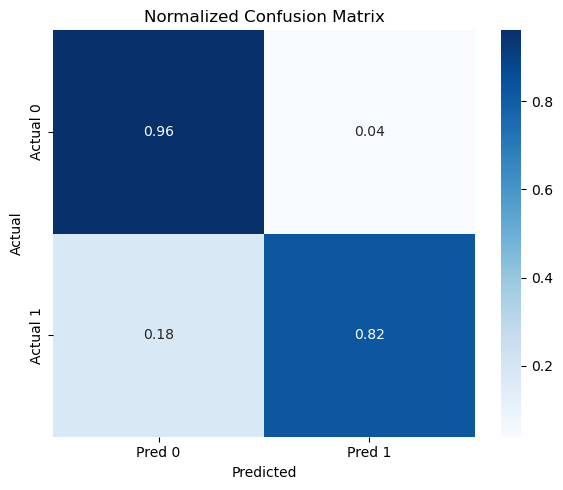

In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# compute confusion matrix
cm = confusion_matrix(yte, yhat)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


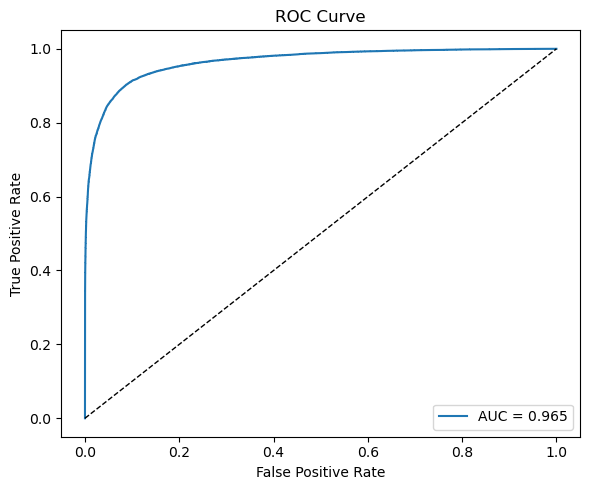

In [49]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve values
fpr, tpr, thresholds = roc_curve(yte, p_te)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [51]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------------------------------------------------
# 0) choose a SMALL set of features to lag (do NOT lag all 3k)
# ------------------------------------------------------------

drop_targets = {"NACCUDSD", "naccudsd_bin"}
candidate_cols = [c for c in x_train_sub.columns if c not in drop_targets]

# numeric-only
num_cols = [
    c for c in candidate_cols
    if np.issubdtype(x_train_sub[c].dtype, np.number)
]

# y aligned to x_train_sub
y_train = pd.Series(y_train_sub_bin).loc[x_train_sub.index].astype(float)

corrs = []
y_vals = y_train.values

for c in num_cols:
    x_vals = x_train_sub[c].values.astype(float)
    m = ~np.isnan(x_vals) & ~np.isnan(y_vals)
    if m.sum() < 10:
        continue
    try:
        cor = np.corrcoef(x_vals[m], y_vals[m])[0, 1]
    except Exception:
        continue
    if not np.isnan(cor):
        corrs.append((c, abs(cor)))

# take top N numeric predictors
top_n = 100
corrs_sorted = sorted(corrs, key=lambda t: t[1], reverse=True)
lag_base_cols = [c for c, _ in corrs_sorted[:top_n]]

# always include days_since_prev if present (even if not in top 40)
if "days_since_prev" in x_train_sub.columns and "days_since_prev" not in lag_base_cols:
    lag_base_cols.append("days_since_prev")

print(f"using {len(lag_base_cols)} features for lags:")
print(lag_base_cols)

id_col = "NACCID"
time_col = "visit_date"
lags = (1, 2, 3)

# ------------------------------------------------------------
# 1) helper to make per-subject lag features (on sub_pruned)
# ------------------------------------------------------------

def make_lags(df: pd.DataFrame,
              id_col: str,
              time_col: str,
              cols: list[str],
              lags=(1, 2, 3)) -> pd.DataFrame:
    # sort by id + time to respect temporal ordering
    tmp = df[[id_col, time_col] + cols].sort_values([id_col, time_col]).copy()

    for k in lags:
        for c in cols:
            tmp[f"{c}_lag{k}"] = tmp.groupby(id_col, sort=False)[c].shift(k)

    # simple visit counter within subject (optional extra signal)
    tmp["visits_in_window"] = tmp.groupby(id_col, sort=False).cumcount()

    # restore original index so we can slice by x_train_sub/x_test_sub indices
    tmp.index = df.index
    return tmp

# ------------------------------------------------------------
# 2) build lagged frame on the full sub_pruned, then slice by split
# ------------------------------------------------------------

lagged_full = make_lags(
    df=sub_pruned,
    id_col=id_col,
    time_col=time_col,
    cols=lag_base_cols,
    lags=lags,
)

# align to your existing temporal split
Xtr = lagged_full.loc[x_train_sub.index].copy()
Xte = lagged_full.loc[x_test_sub.index].copy()

# all lagged feature names
lag_feats = [
    c for c in Xtr.columns
    if any(c.endswith(f"_lag{k}") for k in lags)
]

# keep unlagged days_since_prev as a contemporaneous feature if present
if "days_since_prev" in Xtr.columns:
    lag_feats.append("days_since_prev")

# drop rows without at least lag1 (needs enough history)
lag1_feats = [c for c in lag_feats if c.endswith("_lag1")]
Xtr = Xtr.dropna(subset=lag1_feats)
Xte = Xte.dropna(subset=lag1_feats)

# y aligned to the new (shrunk) X indices
ytr = pd.Series(y_train_sub_bin).loc[Xtr.index].astype(np.int32)
yte = pd.Series(y_test_sub_bin).loc[Xte.index].astype(np.int32)

print("Xtr shape (rows, lag_feats):", Xtr.shape[0], len(lag_feats))
print("Xte shape (rows, lag_feats):", Xte.shape[0], len(lag_feats))

# ------------------------------------------------------------
# 3) fit XGBoost on the compact lag feature set
# ------------------------------------------------------------

clf = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.07,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    max_bin=256,
    n_jobs=4,
    random_state=42,
)

clf.fit(Xtr[lag_feats].astype(np.float32), ytr)

# ------------------------------------------------------------
# 4) predict + basic metrics
# ------------------------------------------------------------

p_test_xgb = clf.predict_proba(Xte[lag_feats].astype(np.float32))[:, 1]
thr = 0.5
y_pred = (p_test_xgb >= thr).astype(int)

xgb_accuracy  = float(accuracy_score(yte, y_pred))
xgb_precision = float(precision_score(yte, y_pred, zero_division=0))
xgb_recall    = float(recall_score(yte, y_pred, zero_division=0))
xgb_f1        = float(f1_score(yte, y_pred, zero_division=0))

print({
    "xgb_accuracy":  xgb_accuracy,
    "xgb_precision": xgb_precision,
    "xgb_recall":    xgb_recall,
    "xgb_f1":        xgb_f1,
})

C:\Users\miked\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\miked\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


using 101 features for lags:
['MEMORY', 'REMDATES', 'TRAVEL', 'TAXES', 'JUDGMENT', 'BILLS', 'CRAFTDRE', 'COMMUN', 'SHOPPING', 'MOCARECN', 'HOMEHOBB', 'UDSBENTD', 'VEG', 'ORIENT', 'EVENTS', 'MEALPREP', 'ANIMALS', 'PAYATTN', 'GAMES', 'STOVE', 'PERSCARE', 'CRAFTCUE', 'MOCAORDT', 'DIGBACCT', 'UDSVERTN', 'APA', 'MOCASER7', 'TRAILBLI', 'MOCACLOH', 'MOCAORDY', 'MOCAREGI', 'MOCAORPL', 'invalid_MOCARECR', 'MOCAORYR', 'MOCAFLUE', 'MOCAABST', 'MOCACLON', 'MOCATRAI', 'MINTPCNG', 'MEMPROB', 'MOCAORMO', 'MOCAREPE', 'AGIT', 'MOCALETT', 'MINTTOTW', 'ANX', 'MOCARECR', 'MOT', 'invalid_TRAILB', 'invalid_TRAILBLI', 'invalid_TRAILBRR', 'DIGFORCT', 'IRR', 'DISN', 'invalid_NACCDAGE', 'invalid_NACCMOD', 'invalid_NACCYOD', 'NACCYOD', 'invalid_NACCINT', 'APP', 'TRAILA', 'UDSBENTC', 'MOCACUBE', 'MOCANAMI', 'NACCDAGE', 'MOCADIGI', 'NITE', 'MINTSCNG', 'DEPD', 'NACCMOD', 'PARKSIGN', 'DEL', 'TRAILALI', 'MOCAORCT', 'invalid_MOCARECC', 'MEMUNITS', 'LOGIMEM', 'HALL', 'BRADY', 'NACCNVST', 'SLOWINGL', 'SLOWINGR', 'NACCIN

C:\Users\miked\AppData\Local\Temp\ipykernel_25080\2058234853.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp[f"{c}_lag{k}"] = tmp.groupby(id_col, sort=False)[c].shift(k)
C:\Users\miked\AppData\Local\Temp\ipykernel_25080\2058234853.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tmp[f"{c}_lag{k}"] = tmp.groupby(id_col, sort=False)[c].shift(k)
C:\Users\miked\AppData\Local\Temp\ipykernel_25080\2058234853.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

Xtr shape (rows, lag_feats): 23288 304
Xte shape (rows, lag_feats): 44994 304
{'xgb_accuracy': 0.892141174378806, 'xgb_precision': 0.8587590721502775, 'xgb_recall': 0.8079935730066279, 'xgb_f1': 0.8326032216894899}


In [53]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------------------
# 0) use ALL engineered features (no lags)
# -----------------------------------------

# drop target + clear non-feature columns if they slipped in
drop_cols = {"NACCUDSD", "naccudsd_bin", "NACCID", "visit_date"}

Xtr_full = x_train_sub.drop(
    columns=[c for c in drop_cols if c in x_train_sub.columns],
    errors="ignore",
).copy()

Xte_full = x_test_sub.drop(
    columns=[c for c in drop_cols if c in x_test_sub.columns],
    errors="ignore",
).copy()

# keep only numeric columns (xgboost expects numeric)
num_cols = [
    c for c in Xtr_full.columns
    if np.issubdtype(Xtr_full[c].dtype, np.number)
]

Xtr = Xtr_full[num_cols].astype(np.float32)
Xte = Xte_full[num_cols].astype(np.float32)

ytr = pd.Series(y_train_sub_bin).loc[Xtr.index].astype(np.int32)
yte = pd.Series(y_test_sub_bin).loc[Xte.index].astype(np.int32)

print("xgboost full-feature train shape:", Xtr.shape)
print("xgboost full-feature test shape:", Xte.shape)

# -----------------------------------------
# 1) fit xgboost on all features
# -----------------------------------------

clf_full = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.07,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    tree_method="hist",
    max_bin=256,
    n_jobs=4,
    random_state=42,
)

clf_full.fit(Xtr, ytr)

# -----------------------------------------
# 2) predict + metrics
# -----------------------------------------

p_test_xgb_full = clf_full.predict_proba(Xte)[:, 1]
thr = 0.5
y_pred_full = (p_test_xgb_full >= thr).astype(int)

xgb_full_accuracy  = float(accuracy_score(yte, y_pred_full))
xgb_full_precision = float(precision_score(yte, y_pred_full, zero_division=0))
xgb_full_recall    = float(recall_score(yte, y_pred_full, zero_division=0))
xgb_full_f1        = float(f1_score(yte, y_pred_full, zero_division=0))

print({
    "xgb_full_accuracy":  xgb_full_accuracy,
    "xgb_full_precision": xgb_full_precision,
    "xgb_full_recall":    xgb_full_recall,
    "xgb_full_f1":        xgb_full_f1,
})


xgboost full-feature train shape: (39290, 496)
xgboost full-feature test shape: (60830, 496)
{'xgb_full_accuracy': 0.9238369225710998, 'xgb_full_precision': 0.8983246678220682, 'xgb_full_recall': 0.8809782352108021, 'xgb_full_f1': 0.889566896288704}


<Figure size 1000x800 with 0 Axes>

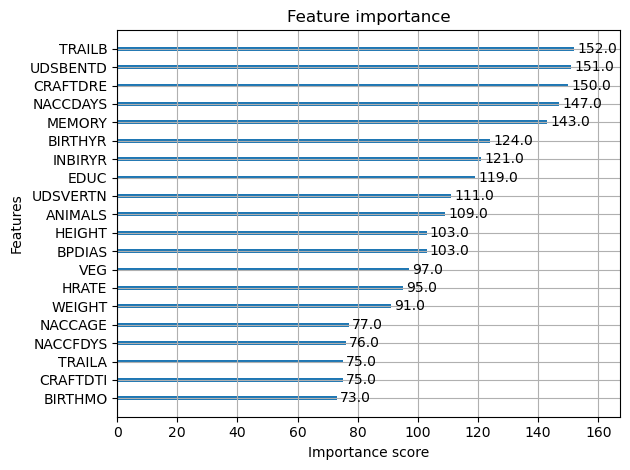

In [61]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(clf_full, max_num_features=20)
plt.tight_layout()
plt.show()



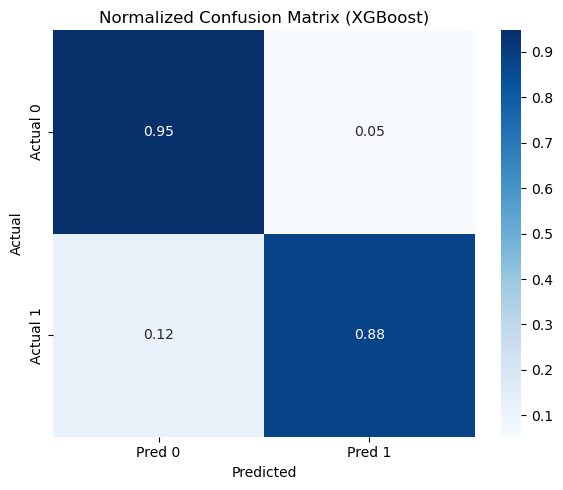

In [67]:

# compute confusion matrix using your predicted labels
cm = confusion_matrix(yte, y_pred_full)

# normalize by row (actual class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Normalized Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [69]:
# ----- GEE with reduced dimensionality (robust version)

import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Autoregressive, Exchangeable
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------------------------------------------------
# 0) reduce dimensionality for GEE: small numeric feature set
# ------------------------------------------------------------

drop_targets = {"NACCUDSD", "naccudsd_bin"}

# base X for train/test, without targets
x_train_ge_full = x_train_sub.drop(
    columns=[c for c in drop_targets if c in x_train_sub.columns],
    errors="ignore",
)
x_test_ge_full = x_test_sub.drop(
    columns=[c for c in drop_targets if c in x_test_sub.columns],
    errors="ignore",
)

# numeric-only columns
num_cols = [
    c for c in x_train_ge_full.columns
    if np.issubdtype(x_train_ge_full[c].dtype, np.number)
]

y_train_full = pd.Series(y_train_sub_bin).loc[x_train_ge_full.index].astype(float)
y_vals = y_train_full.values

corrs = []

for c in num_cols:
    x_vals = x_train_ge_full[c].values.astype(float)
    m = ~np.isnan(x_vals) & ~np.isnan(y_vals)
    if m.sum() < 10:
        continue
    try:
        cor = np.corrcoef(x_vals[m], y_vals[m])[0, 1]
    except Exception:
        continue
    if not np.isnan(cor):
        corrs.append((c, abs(cor)))

# take top N numeric predictors
top_n = 50  # match your LR setting
corrs_sorted = sorted(corrs, key=lambda t: t[1], reverse=True)
keep_cols = [c for c, _ in corrs_sorted[:top_n]]

# always include days_since_prev if available
if "days_since_prev" in x_train_ge_full.columns and "days_since_prev" not in keep_cols:
    keep_cols.append("days_since_prev")

print("gee using features:", keep_cols)

x_train_ge = x_train_ge_full[keep_cols].copy()
x_test_ge = x_test_ge_full[keep_cols].copy()

# ------------------------------------------------------------
# 1) last-step imputation and variance check
# ------------------------------------------------------------

# mean-impute remaining NaNs so GEE doesn't choke
imp_ge = SimpleImputer(strategy="mean")

x_train_ge_imp = pd.DataFrame(
    imp_ge.fit_transform(x_train_ge),
    index=x_train_ge.index,
    columns=x_train_ge.columns
)
x_test_ge_imp = pd.DataFrame(
    imp_ge.transform(x_test_ge),
    index=x_test_ge.index,
    columns=x_test_ge.columns
)

# drop any zero-variance columns (constant within train)
var0 = x_train_ge_imp.var(axis=0)
drop_const = var0[var0 == 0.0].index.tolist()

if drop_const:
    print("gee dropping constant columns:", drop_const)
    x_train_ge_imp = x_train_ge_imp.drop(columns=drop_const)
    x_test_ge_imp = x_test_ge_imp.drop(
        columns=[c for c in drop_const if c in x_test_ge_imp.columns],
        errors="ignore"
    )

# fixed-effects design matrices with intercept
fe_tr = sm.add_constant(x_train_ge_imp, has_constant="add")
fe_te = sm.add_constant(x_test_ge_imp,  has_constant="add")

# ------------------------------------------------------------
# 2) groups and time (ensure per-subject ordering for AR(1))
# ------------------------------------------------------------

# subject ids for train rows
g_tr = sub_pruned.loc[fe_tr.index, "NACCID"]

# build per-subject time index based on visit_date
df_time = sub_pruned.loc[fe_tr.index, ["NACCID", "visit_date"]].sort_values(
    ["NACCID", "visit_date"]
)
time_tr = df_time.groupby("NACCID", sort=False).cumcount().reindex(fe_tr.index)

# ------------------------------------------------------------
# 3) fit GEE with AR(1), fallback to Exchangeable
# ------------------------------------------------------------

endog = pd.Series(y_train_sub_bin).loc[fe_tr.index].astype(int)

try:
    cov = Autoregressive()
    gee = GEE(
        endog=endog,
        exog=fe_tr,
        groups=g_tr,
        time=time_tr,
        family=Binomial(),
        cov_struct=cov,
    )
    gee_res = gee.fit(maxiter=100)
except Exception:
    cov = Exchangeable()
    gee = GEE(
        endog=endog,
        exog=fe_tr,
        groups=g_tr,
        family=Binomial(),
        cov_struct=cov,
    )
    gee_res = gee.fit(maxiter=100)

print(gee_res.summary())

# ------------------------------------------------------------
# 4) predict + metrics on test set
# ------------------------------------------------------------

p_test_gee = gee_res.predict(fe_te)

# if any nans sneak in, treat them as 0.5 so they don't silently kill metrics
p_test_gee = np.asarray(p_test_gee, dtype=float)
nan_mask = np.isnan(p_test_gee)
if nan_mask.any():
    print("warning: gee predict returned NaNs; replacing with 0.5 for metrics")
    p_test_gee[nan_mask] = 0.5

thr = 0.5
y_pred = (p_test_gee >= thr).astype(int)

y_test = pd.Series(y_test_sub_bin).loc[fe_te.index].astype(int).to_numpy()

gee_accuracy  = float(accuracy_score(y_test, y_pred))
gee_precision = float(precision_score(y_test, y_pred, zero_division=0))
gee_recall    = float(recall_score(y_test, y_pred, zero_division=0))
gee_f1        = float(f1_score(y_test, y_pred, zero_division=0))

print({
    "gee_accuracy":  gee_accuracy,
    "gee_precision": gee_precision,
    "gee_recall":    gee_recall,
    "gee_f1":        gee_f1,
})


C:\Users\miked\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\miked\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


gee using features: ['MEMORY', 'REMDATES', 'TRAVEL', 'TAXES', 'JUDGMENT', 'BILLS', 'CRAFTDRE', 'COMMUN', 'SHOPPING', 'MOCARECN', 'HOMEHOBB', 'UDSBENTD', 'VEG', 'ORIENT', 'EVENTS', 'MEALPREP', 'ANIMALS', 'PAYATTN', 'GAMES', 'STOVE', 'PERSCARE', 'CRAFTCUE', 'MOCAORDT', 'DIGBACCT', 'UDSVERTN', 'APA', 'MOCASER7', 'TRAILBLI', 'MOCACLOH', 'MOCAORDY', 'MOCAREGI', 'MOCAORPL', 'invalid_MOCARECR', 'MOCAORYR', 'MOCAFLUE', 'MOCAABST', 'MOCACLON', 'MOCATRAI', 'MINTPCNG', 'MEMPROB', 'MOCAORMO', 'MOCAREPE', 'AGIT', 'MOCALETT', 'MINTTOTW', 'ANX', 'MOCARECR', 'MOT', 'invalid_TRAILB', 'invalid_TRAILBLI', 'days_since_prev']


C:\Users\miked\anaconda3\Lib\site-packages\statsmodels\genmod\cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(
C:\Users\miked\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_estimating_equations.py:1300: IterationLimitWarning: Iteration limit reached prior to convergence
  warnings.warn("Iteration limit reached prior to convergence",


                               GEE Regression Results                              
Dep. Variable:                naccudsd_bin   No. Observations:                39290
Model:                                 GEE   No. clusters:                    16002
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   9
Family:                           Binomial   Mean cluster size:                 2.5
Dependence structure:         Exchangeable   Num. iterations:                   100
Date:                     Wed, 03 Dec 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         13:26:49
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.5942      0.203     27.552      0.000       5.196  

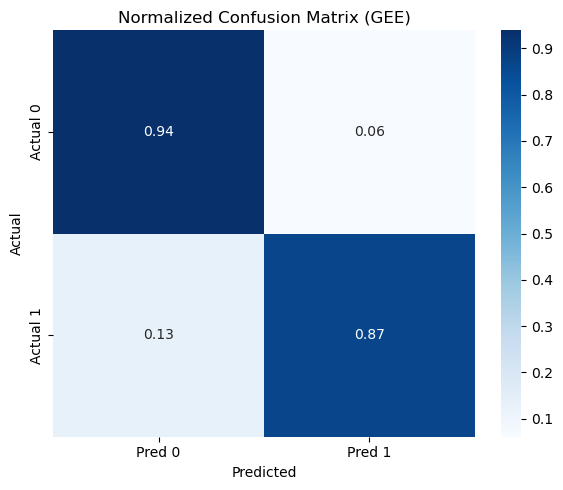

Raw Confusion Matrix:
[[37229  2420]
 [ 2805 18376]]


In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# raw confusion matrix
cm = confusion_matrix(y_test, y_pred)

# normalized by true class
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Normalized Confusion Matrix (GEE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Raw Confusion Matrix:")
print(cm)


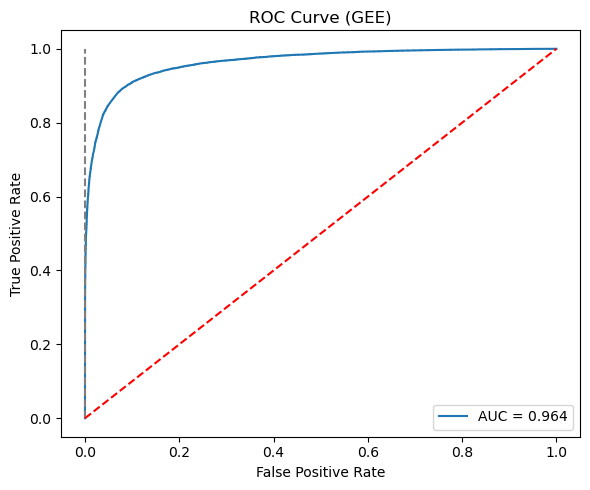

In [73]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# compute ROC points
fpr, tpr, thresholds = roc_curve(y_test, p_test_gee)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 0], [0, 1], linestyle="--", color="gray")  # left border
plt.plot([0, 1], [0, 1], linestyle="--", color="red")   # chance line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (GEE)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Fit HMM as a Predictive Model on NACCUDSD Sequences

In [75]:
from hmmlearn.hmm import MultinomialHMM
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

id_col = "NACCID"
time_col = "visit_date"

# ------------------------------------------------------------
# 0) labels -> integers [0..n_obs-1]
# ------------------------------------------------------------
ytr_mc = pd.Series(y_train_sub_mc).astype(int)
yte_mc = pd.Series(y_test_sub_mc).astype(int)

all_labels = pd.Index(sorted(pd.unique(pd.concat([ytr_mc, yte_mc], axis=0))))
lab2int = {lab: i for i, lab in enumerate(all_labels)}
int2lab = {i: lab for lab, i in lab2int.items()}

n_obs = len(all_labels)

# train/test frames with encoded observations
train_df = sub_pruned.loc[x_train_sub.index, [id_col, time_col]].copy()
train_df["y_enc"] = ytr_mc.map(lab2int).astype(int)
train_df = train_df.sort_values([id_col, time_col])

test_df = sub_pruned.loc[x_test_sub.index, [id_col, time_col]].copy()
test_df["y_enc"] = yte_mc.map(lab2int).astype(int)
test_df = test_df.sort_values([id_col, time_col])

def build_sequences(df, id_col, enc_col):
    lengths = df.groupby(id_col, sort=False).size().tolist()
    x = df[enc_col].to_numpy()
    return x, lengths

x_train_int, lengths_train = build_sequences(train_df, id_col=id_col, enc_col="y_enc")

# ------------------------------------------------------------
# 1) choose model class depending on hmmlearn version
# ------------------------------------------------------------
use_categorical = False
try:
    from hmmlearn.hmm import CategoricalHMM
    use_categorical = True
except ImportError:
    from hmmlearn.hmm import MultinomialHMM

# ------------------------------------------------------------
# 2) fit baseline HMM with n_states = 3
# ------------------------------------------------------------
n_states = 3  # main model; we will tune this below

if use_categorical:
    x_train = x_train_int.reshape(-1, 1).astype(int)
    hmm = CategoricalHMM(
        n_components=n_states,
        n_iter=300,
        tol=1e-3,
        random_state=42,
        verbose=False
    )
    hmm.fit(x_train, lengths=lengths_train)
else:
    eye = np.eye(n_obs, dtype=int)
    x_train = eye[x_train_int]  # one-hot rows
    hmm = MultinomialHMM(
        n_components=n_states,
        n_iter=300,
        tol=1e-3,
        random_state=42,
        verbose=False
    )
    hmm.fit(x_train, lengths=lengths_train)

A = hmm.transmat_       # transition matrix
B = hmm.emissionprob_   # emission matrix
pi = hmm.startprob_.reshape(1, -1)  # row vector


HMM tuning results over number of states:
   n_states  accuracy  precision    recall        f1       auc
0         2  0.651800   0.162950  0.250000  0.197300  0.433304
1         3  0.623377   0.295288  0.426775  0.318504  0.740522
2         4  0.681900   0.472396  0.527816  0.469065  0.847263
3         5  0.681851   0.472375  0.527657  0.468918  0.847448


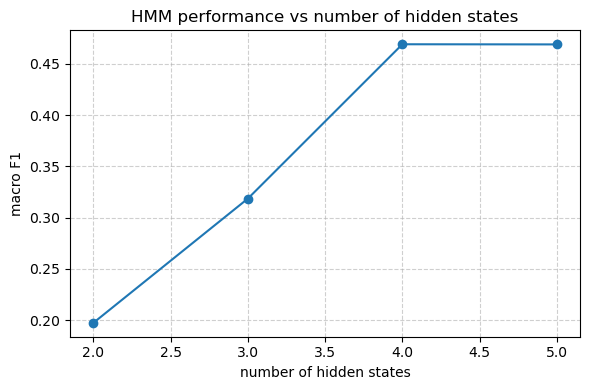

In [79]:
# ------------------------------------------------------------
# 7) tuning experiment: vary number of hidden states
#    (simple sweep over n_states for metrics)
# ------------------------------------------------------------
state_candidates = [2, 3, 4, 5]
tuning_results = []

for k in state_candidates:
    if use_categorical:
        x_train_k = x_train_int.reshape(-1, 1).astype(int)
        hmm_k = CategoricalHMM(
            n_components=k,
            n_iter=250,      # slightly fewer iters for sweep
            tol=1e-3,
            random_state=42,
            verbose=False
        )
        hmm_k.fit(x_train_k, lengths=lengths_train)
    else:
        x_train_k = eye[x_train_int]
        hmm_k = MultinomialHMM(
            n_components=k,
            n_iter=250,
            tol=1e-3,
            random_state=42,
            verbose=False
        )
        hmm_k.fit(x_train_k, lengths=lengths_train)

    A_k = hmm_k.transmat_
    B_k = hmm_k.emissionprob_
    pi_k = hmm_k.startprob_.reshape(1, -1)

    y_true_k, y_pred_k, y_score_k = [], [], []

    for sid, g in test_df.groupby(id_col, sort=False):
        obs = g["y_enc"].to_numpy()
        if len(obs) == 0:
            continue

        alpha = pi_k.copy()

        for o_t in obs:
            pred_obs_dist = alpha @ A_k @ B_k
            y_score_k.append(pred_obs_dist.ravel())
            y_pred_k.append(int(np.argmax(pred_obs_dist)))
            y_true_k.append(int(o_t))

            alpha = alpha @ A_k
            alpha = alpha * B_k[:, o_t][None, :]
            s = alpha.sum()
            alpha = (alpha / s) if s > 0 else pi_k.copy()

    y_true_k = np.asarray(y_true_k, dtype=int)
    y_pred_k = np.asarray(y_pred_k, dtype=int)
    y_score_k = np.vstack(y_score_k)

    acc_k  = float(accuracy_score(y_true_k, y_pred_k))
    prec_k = float(precision_score(y_true_k, y_pred_k, average="macro", zero_division=0))
    rec_k  = float(recall_score(y_true_k, y_pred_k, average="macro", zero_division=0))
    f1_k   = float(f1_score(y_true_k, y_pred_k, average="macro", zero_division=0))
    try:
        auc_k = float(
            roc_auc_score(
                y_true_k,
                y_score_k,
                multi_class="ovr",
                average="macro"
            )
        )
    except ValueError:
        auc_k = float("nan")

    tuning_results.append({
        "n_states": k,
        "accuracy": acc_k,
        "precision": prec_k,
        "recall": rec_k,
        "f1": f1_k,
        "auc": auc_k
    })

tuning_df = pd.DataFrame(tuning_results)
print("\nHMM tuning results over number of states:")
print(tuning_df)

# optional: quick plot of F1 vs n_states
plt.figure(figsize=(6, 4))
plt.plot(tuning_df["n_states"], tuning_df["f1"], marker="o")
plt.xlabel("number of hidden states")
plt.ylabel("macro F1")
plt.title("HMM performance vs number of hidden states")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [77]:
# ------------------------------------------------------------
# 3) evaluate HMM: macro metrics + AUC + confusion matrix
# ------------------------------------------------------------
y_true_all, y_pred_all = [], []
y_score_all = []  # predictive distributions for AUC

for sid, g in test_df.groupby(id_col, sort=False):
    obs = g["y_enc"].to_numpy()
    if len(obs) == 0:
        continue

    alpha = pi.copy()  # 1 x n_states

    for o_t in obs:
        # predict next observation before seeing o_t
        pred_obs_dist = alpha @ A @ B  # 1 x n_obs

        # store scores and hard label
        y_score_all.append(pred_obs_dist.ravel())
        y_pred_all.append(int(np.argmax(pred_obs_dist)))
        y_true_all.append(int(o_t))

        # forward update with actual o_t
        alpha = alpha @ A
        alpha = alpha * B[:, o_t][None, :]
        s = alpha.sum()
        alpha = (alpha / s) if s > 0 else pi.copy()

y_true_all = np.asarray(y_true_all, dtype=int)
y_pred_all = np.asarray(y_pred_all, dtype=int)
y_score_all = np.vstack(y_score_all)  # shape: (N_test_points, n_obs)

# macro metrics
hmm_accuracy  = float(accuracy_score(y_true_all, y_pred_all))
hmm_precision = float(precision_score(y_true_all, y_pred_all, average="macro", zero_division=0))
hmm_recall    = float(recall_score(y_true_all, y_pred_all, average="macro", zero_division=0))
hmm_f1        = float(f1_score(y_true_all, y_pred_all, average="macro", zero_division=0))

try:
    hmm_auc = float(
        roc_auc_score(
            y_true_all,
            y_score_all,
            multi_class="ovr",
            average="macro"
        )
    )
except ValueError:
    hmm_auc = float("nan")

print({
    "hmm_accuracy":  hmm_accuracy,
    "hmm_precision": hmm_precision,
    "hmm_recall":    hmm_recall,
    "hmm_f1":        hmm_f1,
    "hmm_auc":       hmm_auc,
    "n_states":      int(n_states),
    "n_obs_levels":  int(n_obs),
    "n_test_points_scored": int(len(y_true_all)),
    "impl": "categoricalhmm" if use_categorical else "multinomialhmm(one-hot)"
})

{'hmm_accuracy': 0.6233766233766234, 'hmm_precision': 0.2952879142237469, 'hmm_recall': 0.4267748657408792, 'hmm_f1': 0.31850405914592933, 'hmm_auc': 0.7404573064492346, 'n_states': 3, 'n_obs_levels': 4, 'n_test_points_scored': 60830, 'impl': 'categoricalhmm'}


In [81]:
# confusion matrix + report
cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(n_obs)))
print("confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(
    cm,
    index=[f"true_{int2lab[i]}" for i in range(n_obs)],
    columns=[f"pred_{int2lab[i]}" for i in range(n_obs)]
))

print("\nclassification report (by label):")
print(classification_report(
    y_true_all,
    y_pred_all,
    target_names=[str(int2lab[i]) for i in range(n_obs)],
    zero_division=0
))

confusion matrix (rows=true, cols=pred):
        pred_1  pred_2  pred_3  pred_4
true_1   29527       0       0   10122
true_2    1618       0       0    1025
true_3    2535       0       0    7282
true_4     328       0       0    8393

classification report (by label):
              precision    recall  f1-score   support

           1       0.87      0.74      0.80     39649
           2       0.00      0.00      0.00      2643
           3       0.00      0.00      0.00      9817
           4       0.31      0.96      0.47      8721

    accuracy                           0.62     60830
   macro avg       0.30      0.43      0.32     60830
weighted avg       0.61      0.62      0.59     60830



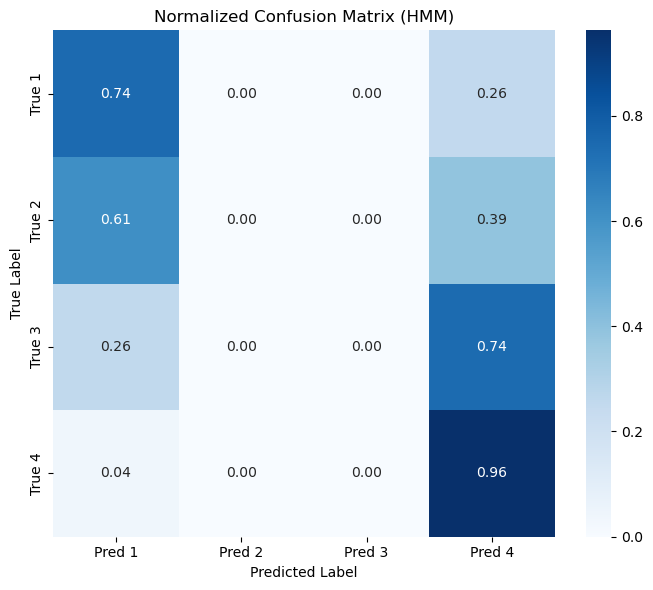


Classification Report:
              precision    recall  f1-score   support

           1       0.87      0.74      0.80     39649
           2       0.00      0.00      0.00      2643
           3       0.00      0.00      0.00      9817
           4       0.31      0.96      0.47      8721

    accuracy                           0.62     60830
   macro avg       0.30      0.43      0.32     60830
weighted avg       0.61      0.62      0.59     60830



In [87]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# compute confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(n_obs)))

# create dataframe with readable labels
cm_df = pd.DataFrame(
    cm,
    index=[f"True {int2lab[i]}" for i in range(n_obs)],
    columns=[f"Pred {int2lab[i]}" for i in range(n_obs)]
)

# plot normalized confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_df.div(cm_df.sum(axis=1), axis=0),   # normalize by true class
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("Normalized Confusion Matrix (HMM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# classification report
print("\nClassification Report:")
print(classification_report(
    y_true_all,
    y_pred_all,
    target_names=[str(int2lab[i]) for i in range(n_obs)],
    zero_division=0
))


In [ ]:
#### Metric Comparison for ML Methods

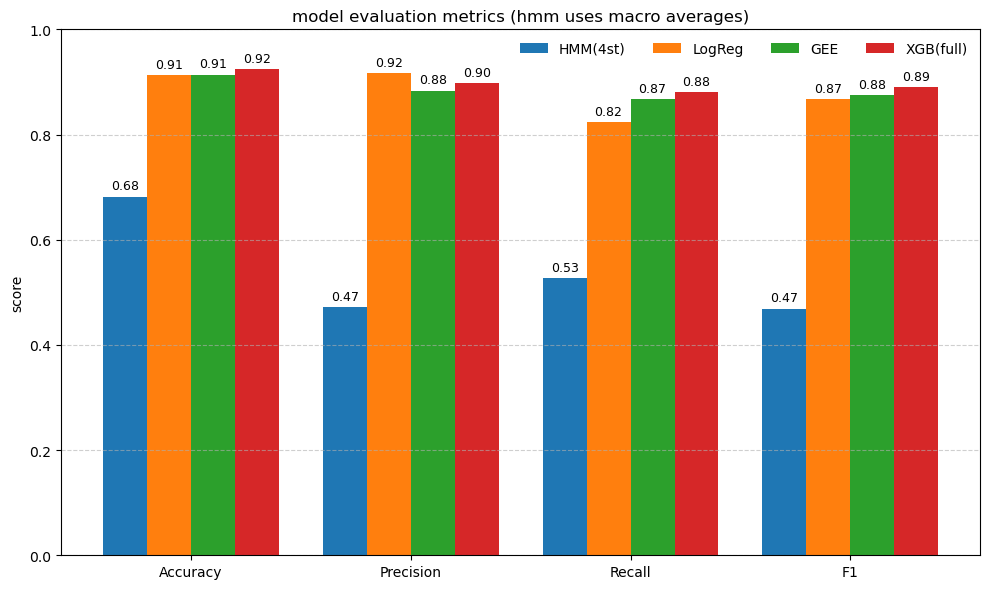

In [85]:
# ------------------------------------------------------------
# 6) compare HMM metrics to other models (using your stored values)
# ------------------------------------------------------------
metrics = {
    "HMM(4st)": {
        "Accuracy": 0.6819,
        "Precision": 0.472396,
        "Recall": 0.527816,
        "F1": 0.469065
    },
    "LogReg": {
        "Accuracy": 0.912773303,
        "Precision": 0.917433605,
        "Recall": 0.823615504,
        "F1": 0.867996816
    },
    "GEE": {
        "Accuracy": 0.914104882,
        "Precision": 0.88363146,
        "Recall": 0.867569992,
        "F1": 0.875527074
    },
    "XGB(full)": {
        "Accuracy": 0.923836923,
        "Precision": 0.898324668,
        "Recall": 0.880978235,
        "F1": 0.889566896
    }
}

labels = ["Accuracy", "Precision", "Recall", "F1"]
models = list(metrics.keys())
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    vals = [metrics[model][k] for k in labels]
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=model)
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.2f}",
                    xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 1.0)
ax.set_ylabel("score")
ax.set_title("model evaluation metrics (hmm uses macro averages)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(ncol=4, frameon=False)
fig.tight_layout()

plt.savefig("model_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## HMM Discovery

In [ ]:
# ============================================================
# HMM for discovery: full longitudinal dataset (no train/test)
# ============================================================
id_col   = "NACCID"
time_col = "visit_date"
obs_col  = "NACCUDSD"   # multiclass clinical diagnosis label

# ------------------------------------------------------------
# 0) build full longitudinal frame for HMM (all subjects/visits)
# ------------------------------------------------------------
hmm_df = sub_pruned.copy()   # <- use your main processed df
hmm_df = hmm_df[[id_col, time_col, obs_col] + 
                [c for c in sub_pruned.columns 
                 if c not in {id_col, time_col, obs_col}]].copy()

# keep only rows with a valid diagnosis + visit date
hmm_df = hmm_df.dropna(subset=[obs_col, time_col])
hmm_df[time_col] = pd.to_datetime(hmm_df[time_col], errors="coerce")
hmm_df = hmm_df.dropna(subset=[time_col])

# sort longitudinally
hmm_df = hmm_df.sort_values([id_col, time_col]).reset_index(drop=True)

print("hmm_df shape after filtering:", hmm_df.shape)
print("unique subjects:", hmm_df[id_col].nunique())

In [ ]:
# ------------------------------------------------------------
# 1) encode diagnosis labels -> integers [0..n_obs-1]
# ------------------------------------------------------------
y_all = hmm_df[obs_col].astype(int)

all_labels = pd.Index(sorted(pd.unique(y_all)))
lab2int = {lab: i for i, lab in enumerate(all_labels)}
int2lab = {i: lab for lab, i in lab2int.items()}
n_obs   = len(all_labels)

hmm_df["obs_int"] = y_all.map(lab2int).astype(int)

print("n_obs (distinct NACCUDSD levels):", n_obs)
print("label mapping:", lab2int)

In [ ]:
# ------------------------------------------------------------
# 2) build sequences: X (stacked obs) + lengths per subject
# ------------------------------------------------------------
def build_sequences_full(df: pd.DataFrame, id_col: str, enc_col: str):
    lengths = df.groupby(id_col, sort=False).size().tolist()
    x = df[enc_col].to_numpy()
    return x, lengths

x_int, lengths = build_sequences_full(hmm_df, id_col=id_col, enc_col="obs_int")

print("total visits:", len(x_int))
print("total subjects:", len(lengths))


In [ ]:
# ------------------------------------------------------------
# 3) choose HMM class depending on hmmlearn version
# ------------------------------------------------------------
use_categorical = False
try:
    from hmmlearn.hmm import CategoricalHMM
    use_categorical = True
except ImportError:
    from hmmlearn.hmm import MultinomialHMM

In [ ]:
# ------------------------------------------------------------
# 4) fit HMM on ALL subjects/visits (unsupervised progression)
# ------------------------------------------------------------
n_states = 4  # you can change to 2/4/5 later for interpretability checks

if use_categorical:
    X_all = x_int.reshape(-1, 1).astype(int)
    hmm_disc = CategoricalHMM(
        n_components=n_states,
        n_iter=300,
        tol=1e-3,
        random_state=42,
        verbose=False
    )
    hmm_disc.fit(X_all, lengths=lengths)
else:
    eye = np.eye(n_obs, dtype=int)
    X_all = eye[x_int]  # one-hot rows
    hmm_disc = MultinomialHMM(
        n_components=n_states,
        n_iter=300,
        tol=1e-3,
        random_state=42,
        verbose=False
    )
    hmm_disc.fit(X_all, lengths=lengths)

A = hmm_disc.transmat_       # transition matrix
B = hmm_disc.emissionprob_   # emission probabilities
pi = hmm_disc.startprob_.reshape(1, -1)

print("\ntransition matrix (rows = from state, cols = to state):")
print(np.round(A, 3))

print("\nemission probabilities (rows = latent states, cols = obs levels):")
print(np.round(B, 3))

In [ ]:
def decode_sequence_disc(obs_enc: np.ndarray) -> np.ndarray:
    """
    Given a sequence of encoded observations, return the most likely
    latent state path using the fitted discovery HMM.
    """
    if use_categorical:
        X = obs_enc.reshape(-1, 1)
        z = hmm_disc.predict(X)
    else:
        eye = np.eye(n_obs, dtype=int)
        X = eye[obs_enc]
        z = hmm_disc.predict(X)
    return z

# easiest: just call predict on full X with lengths to align with hmm_df
if use_categorical:
    X_for_decoding = x_int.reshape(-1, 1).astype(int)
else:
    eye = np.eye(n_obs, dtype=int)
    X_for_decoding = eye[x_int]

z_all = hmm_disc.predict(X_for_decoding, lengths=lengths)
hmm_df["latent_state"] = z_all

print("\nlatent_state value counts:")
print(hmm_df["latent_state"].value_counts().sort_index())


In [ ]:
# Decode latent states over time for example subjects
example_ids = list(hmm_df[id_col].unique())[:3]  # first 5 subjects; update if you want specific ones

fig, axes = plt.subplots(
    len(example_ids),
    1,
    figsize=(10, 2.5 * len(example_ids)),
    sharex=False
)

if len(example_ids) == 1:
    axes = [axes]

for ax, sid in zip(axes, example_ids):
    g = hmm_df.loc[hmm_df[id_col] == sid].sort_values(time_col)
    obs = g["obs_int"].to_numpy()
    if len(obs) == 0:
        continue

    z_decoded = g["latent_state"].to_numpy()  # already aligned

    ax.step(range(len(z_decoded)), z_decoded, where="mid")
    ax.set_title(f"decoded latent states over time — subject {sid}")
    ax.set_xlabel("visit index")
    ax.set_ylabel("latent state")

plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# pick 10 subjects: 7 with changing NACCUDSD, 3 stable
# ------------------------------------------------------------
obs_col = "NACCUDSD"  # change if your diagnosis column has a different name

subj_stats = (
    hmm_df.groupby(id_col)
          .agg(
              n_visits=(obs_col, "size"),
              n_diag=(obs_col, lambda x: x.nunique())
          )
)

# subjects with at least 2 visits and changing diagnosis over time
changing_ids = subj_stats[
    (subj_stats["n_visits"] >= 2) & (subj_stats["n_diag"] > 1)
].index.tolist()

# subjects with at least 2 visits and stable diagnosis
stable_ids = subj_stats[
    (subj_stats["n_visits"] >= 2) & (subj_stats["n_diag"] == 1)
].index.tolist()

print("subjects with changing NACCUDSD:", len(changing_ids))
print("subjects with stable NACCUDSD:", len(stable_ids))

# pick up to 7 changing and 3 stable
example_changing = changing_ids[:7]
example_stable   = stable_ids[:3]

example_ids = example_changing + example_stable
print("example ids used:", example_ids)

# ------------------------------------------------------------
# plot decoded latent states for these subjects
# ------------------------------------------------------------
fig, axes = plt.subplots(
    len(example_ids),
    1,
    figsize=(10, 2.5 * len(example_ids)),
    sharex=False
)

if len(example_ids) == 1:
    axes = [axes]

for ax, sid in zip(axes, example_ids):
    g = hmm_df.loc[hmm_df[id_col] == sid].sort_values(time_col)

    # sanity: require at least 2 visits
    if g.shape[0] < 2:
        continue

    z_decoded = g["latent_state"].to_numpy()
    diag_seq  = g[obs_col].to_numpy()

    # label whether this subject is "changing" or "stable"
    label_type = "changing" if sid in example_changing else "stable"

    ax.step(range(len(z_decoded)), z_decoded, where="mid")
    ax.set_title(f"latent states over time — {label_type} subject {sid}")
    ax.set_xlabel("visit index")
    ax.set_ylabel("latent state")

plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

# clean sequential colormap
im = ax.imshow(A, cmap="Blues", aspect="auto")

ax.set_title("HMM Transition Matrix (Discovery Model)", fontsize=12)
ax.set_xlabel("to state")
ax.set_ylabel("from state")

# dynamic text color based on intensity
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        val = A[i, j]
        text_color = "white" if val > 0.55 else "black"   # works well with Blues
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color=text_color, fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



In [ ]:
# emission probabilities by state (2x2 grid version)
n_states_cur, n_obs_cur = B.shape

# set up a 2x2 grid
n_rows = 2
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8), sharex=True)

# flatten axes for easy indexing
axes = axes.flatten()

x_pos = np.arange(n_obs_cur)
state_labels = [f"state_{s}" for s in range(n_states_cur)]
obs_labels = [int2lab[i] for i in range(n_obs_cur)]

for s in range(n_states_cur):
    ax = axes[s]
    ax.bar(x_pos, B[s])
    ax.set_ylim(0, 1.0)
    ax.set_title(f"emission probabilities ({state_labels[s]})")
    ax.set_ylabel("P(NACCUDSD | state)")

    # add value labels
    for i, v in enumerate(B[s]):
        ax.annotate(f"{v:.2f}", (i, v),
                    textcoords="offset points",
                    xytext=(0, 3),
                    ha="center",
                    va="bottom",
                    fontsize=8)

# set x-axis labels on the last row of plots
for ax in axes[-2:]:
    ax.set_xticks(x_pos)
    ax.set_xticklabels(obs_labels)
    ax.set_xlabel("NACCUDSD label")

# hide unused subplots if n_states < 4
for idx in range(n_states_cur, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# 1) identify all numeric features (drop ID/time/obs/state columns)
non_feat = {id_col, time_col, obs_col, "obs_int", "latent_state"}
numeric_feats = [
    c for c in hmm_df.columns
    if c not in non_feat and pd.api.types.is_numeric_dtype(hmm_df[c])
]

# 2) compute per-state feature means
state_means = hmm_df.groupby("latent_state")[numeric_feats].mean()

# 3) compute global means for standardization
global_means = hmm_df[numeric_feats].mean()

# 4) compute standardized difference from global mean for each state
standardized_profiles = (state_means - global_means)  # "how far from center"
standardized_profiles = standardized_profiles.T  # transpose for readability

print("\n=== STANDARDIZED FEATURE PROFILES ===")
print("Positive = feature is higher in this latent state than global mean")
print("Negative = feature is lower than global mean")
print(standardized_profiles.head(20))

# 5) rank the top defining features per state
top_features_per_state = {}
for s in state_means.index:
    diffs = (state_means.loc[s] - global_means).abs()
    top_features = diffs.sort_values(ascending=False).head(15)
    top_features_per_state[s] = top_features

print("\n=== TOP DEFINING FEATURES PER STATE ===")
for s, feats in top_features_per_state.items():
    print(f"\nlatent_state {s}:")
    print(feats)

In [ ]:
import itertools
# Cohen's Effect Size
# identify numeric features
non_feat = {id_col, time_col, obs_col, "obs_int", "latent_state"}
numeric_feats = [
    c for c in hmm_df.columns
    if c not in non_feat and pd.api.types.is_numeric_dtype(hmm_df[c])
]

def cohens_d(x, y):
    # pooled SD
    nx, ny = len(x), len(y)
    sdx, sdy = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_sd = np.sqrt(((nx-1)*sdx + (ny-1)*sdy) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd if pooled_sd > 0 else 0

states = sorted(hmm_df["latent_state"].unique())
pairwise_effects = {}

for s1, s2 in itertools.combinations(states, 2):
    effect_dict = {}
    for feat in numeric_feats:
        x = hmm_df.loc[hmm_df["latent_state"] == s1, feat]
        y = hmm_df.loc[hmm_df["latent_state"] == s2, feat]
        effect_dict[feat] = cohens_d(x, y)
    df_eff = pd.Series(effect_dict).sort_values(key=lambda x: abs(x), ascending=False)
    pairwise_effects[(s1, s2)] = df_eff

print("\n=== Top Features (Cohen's d) for Each State-Pair Comparison ===")
for pair, effects in pairwise_effects.items():
    print(f"\nStates {pair}:")
    print(effects.head(15))

In [ ]:
# numeric feature columns
num_cols = hmm_df.select_dtypes(include=[np.number]).columns.tolist()

# drop id / time / latent_state from feature set
drop_cols = [id_col, time_col, "latent_state"]
num_cols = [c for c in num_cols if c not in drop_cols]

# per-state means
state_means = hmm_df.groupby("latent_state")[num_cols].mean()

# global mean
global_mean = hmm_df[num_cols].mean()

# standardized profiles: state mean - global mean
std_profiles = state_means.subtract(global_mean, axis="columns")

from math import pi

def radar_plot_state(state_id, profiles, N=8):
    """
    Create a radar plot for one latent state using its
    top N largest standardized deviations from the global mean.
    """
    # pick top N features by absolute deviation
    top_feats = profiles.loc[state_id].abs().sort_values(ascending=False).head(N).index.tolist()
    values = profiles.loc[state_id, top_feats].values.tolist()
    values += [values[0]]  # close the loop

    # angles for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += [angles[0]]

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    # feature names around the circle
    plt.xticks(angles[:-1], top_feats, fontsize=9)

    # zero (global mean) reference circle
    ax.plot(angles, [0] * len(angles), color="gray", linewidth=1, linestyle="--")

    # plot profile
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_title(f"latent state {state_id}: feature profile", size=14, pad=20)

    # make radial axis symmetric for +/– deviations
    max_val = max(max(values), abs(min(values)))
    ax.set_ylim(-max_val, max_val)
    ax.set_rlabel_position(0)
    ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.show()


# generate radar plots for all states
for state_id in std_profiles.index:
    radar_plot_state(state_id, std_profiles, N=8)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cohens_for_pair(pair, pairwise_effects, title=None, topN=12):
    """
    pair: tuple like (0, 1)
    pairwise_effects: dict from your code { (s1,s2): Series of Cohen's d }
    topN: how many top features (by |d|) to show
    """
    if pair not in pairwise_effects:
        print(f"pair {pair} not in pairwise_effects")
        return
    
    d = pairwise_effects[pair]
    
    # sort by absolute effect size, largest first
    d_sorted = d.reindex(d.abs().sort_values(ascending=False).index)
    d_top = d_sorted.head(topN)
    
    # default title if none provided
    if title is None:
        title = f"cohen's d for state {pair[0]} vs state {pair[1]}"
    
    plt.figure(figsize=(8, max(4, 0.4 * topN)))
    
    # color by sign: positive vs negative
    colors = ["#4C72B0" if v > 0 else "#DD8452" for v in d_top.values]
    
    sns.barplot(
        x=d_top.values,
        y=d_top.index,
        orient="h",
        palette=colors
    )
    
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("cohen's d (effect size)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# early vs mci (if your labels are states 2 and 3)
plot_cohens_for_pair(
    (2, 3),
    pairwise_effects,
    title="state 2 (early/normal) vs state 3 (mci)",
    topN=15
)






In [ ]:
# mci vs moderate dementia (3 vs 0)
plot_cohens_for_pair(
    (3, 0),
    pairwise_effects,
    title="state 3 (mci) vs state 0 (moderate dementia)",
    topN=15
)

In [ ]:
# moderate vs severe (0 vs 1)
plot_cohens_for_pair(
    (0, 1),
    pairwise_effects,
    title="state 0 (moderate) vs state 1 (severe dementia)",
    topN=15
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1) hardcode top features per state
# -----------------------------
top_features_per_state_hc = {
    0: {
        "NACCDAYS": 430.343068,
        "NACCFDYS": 302.353241,
        "NACCYOD": 62.08587,
        "INBIRYR": 47.799231,
        "days_since_prev": 28.94667,
        "TRAILB": 27.18873,
        "NACCSTYR": 24.987727,
        "TBIYEAR": 9.016619,
        "BPDIAS": 4.323819,
        "OTRLARR": 3.549619,
        "TRAILA": 3.416231,
        "OTRLBRR": 2.791115,
        "NPWBRWT": 2.522609,
        "NACCDAGE": 2.075164,
        "CRAFTDRE": 1.90481,
    },
    1: {
        "NACCDAYS": 550.660886,
        "NACCYOD": 542.201837,
        "NACCFDYS": 216.846626,
        "TBIYEAR": 32.889868,
        "HRATE": 23.458908,
        "NACCDAGE": 20.798936,
        "INBIRYR": 18.906658,
        "days_since_prev": 17.818369,
        "TRAILB": 17.356054,
        "NACCTIYR": 17.020307,
        "TRAILA": 15.897997,
        "NACCSTYR": 9.423227,
        "BPDIAS": 8.507991,
        "UDSVERTN": 8.375106,
        "ANIMALS": 7.180188,
    },
    2: {
        "NACCDAYS": 347.843597,
        "NACCYOD": 199.114488,
        "NACCFDYS": 170.387911,
        "days_since_prev": 17.034655,
        "TRAILB": 16.731331,
        "NACCSTYR": 12.427027,
        "HRATE": 12.303342,
        "TBIYEAR": 8.090754,
        "NACCTIYR": 7.821508,
        "NACCDAGE": 7.740851,
        "TRAILA": 7.726998,
        "BPDIAS": 5.085011,
        "UDSVERTN": 3.906698,
        "CRAFTDRE": 3.511726,
        "ANIMALS": 3.413956,
    },
    3: {
        "NACCDAYS": 331.798205,
        "NACCFDYS": 255.545518,
        "NACCYOD": 143.265736,
        "INBIRYR": 55.995873,
        "TBIYEAR": 38.049392,
        "HRATE": 34.589904,
        "TRAILB": 6.850932,
        "OTRLBRR": 6.369262,
        "PDYR": 6.187656,
        "OTRLARR": 6.044029,
        "NACCDAGE": 5.452714,
        "WEIGHT": 5.281041,
        "NACCSTYR": 4.034938,
        "NPWBRWT": 2.464616,
        "OTRAILB": 1.837494,
    },
}

# -----------------------------
# 2) build feature x state matrix
# -----------------------------
states = sorted(top_features_per_state_hc.keys())

# union of all features
all_feats = sorted(set().union(*[d.keys() for d in top_features_per_state_hc.values()]))

feat_state_df = pd.DataFrame(index=all_feats, columns=states, dtype=float)

for s in states:
    for feat, val in top_features_per_state_hc[s].items():
        feat_state_df.loc[feat, s] = float(val)

# fill missing entries with 0
feat_state_df = feat_state_df.fillna(0.0)

# sort rows by max absolute value
feat_state_df["max_abs"] = feat_state_df.abs().max(axis=1)
feat_state_df = feat_state_df.sort_values("max_abs", ascending=False)
feat_state_df = feat_state_df.drop(columns=["max_abs"])

# -----------------------------
# 3) NORMALIZE (Z-score per feature across states)
# -----------------------------
feat_state_norm = feat_state_df.apply(
    lambda row: (row - row.mean()) / (row.std() if row.std() != 0 else 1),
    axis=1
)

# -----------------------------
# 4) plot normalized heatmap
# -----------------------------
plt.figure(figsize=(8, max(6, 0.35 * feat_state_norm.shape[0])))
sns.heatmap(
    feat_state_norm,
    cmap="vlag",
    center=0,
    annot=False,
    cbar_kws={"label": "z-score (feature-wise normalization)"},
)
plt.title("Top Defining Features by Latent State (Normalized)")
plt.xlabel("latent state")
plt.ylabel("feature")
plt.tight_layout()
plt.show()


## Model 2 Composites

In [ ]:
comp_corr_in  = comp_df.copy()
comp_corr_out, comp_dropped_all, comp_dropped_by = corr_prune_pipeline(
    comp_corr_in,
    m,
    y_col="naccudsd_bin",
    id_col="NACCID",
    thr=0.80
)

print("comp (after corr): in->", comp_corr_in.shape[1],
      "out->", comp_corr_out.shape[1],
      "dropped->", len(comp_dropped_all))

comp_qc_out, comp_dropped_quasi = drop_quasi_const_hier(
    comp_corr_out,
    id_col="NACCID",
    y_col="naccudsd_bin",
    thr=0.01
)

print("comp quasi-constant dropped:", len(comp_dropped_quasi))

comp_sparse_out = drop_sparse(comp_qc_out, max_missing=0.30)
comp_noleak     = drop_leaky(comp_sparse_out)
comp_clean      = drop_zero_invalid_flags(comp_noleak, prefix="invalid_")

comp_meta_cols = [
    c for c in [
        "NACCID", "NACCADC", "visit_date", "days_since_prev",
        "PACKET", "FORMVER", "NACCUDSD", "naccudsd_bin"
    ]
    if c in comp_clean.columns
]

comp_feat_cols = pick_features_for_model(
    comp_clean,
    exclude=set(comp_meta_cols),
    min_nonmissing=0.70
)

comp_pruned = comp_clean[comp_meta_cols + comp_feat_cols].copy()

print("comp_pruned shape:", comp_pruned.shape)
print("comp feature count:", len(comp_feat_cols))

In [ ]:
# ------------------------------------------------------------
# 6) compare HMM metrics to other models (using your stored values)
# ------------------------------------------------------------
metrics = {
    "HMM": {
        "Accuracy": hmm_accuracy,
        "Precision": hmm_precision,
        "Recall":    hmm_recall,
        "F1":        hmm_f1
    },
    "LogReg": {
        "Accuracy": 0.8179813498983901,
        "Precision": 0.8316518903495363,
        "Recall":    0.636409716536047,
        "F1":        0.7210478651735029
    },
    "GEE": {
        "Accuracy": 0.8092472219419743,
        "Precision": 0.7424408156887257,
        "Recall":    0.7410223417943619,
        "F1":        0.7417309005756659
    },
    "XGB": {
        "Accuracy": 0.8256941858870098,
        "Precision": 0.7597369465389194,
        "Recall":    0.7421087606600952,
        "F1":        0.7508193965879486
    }
}

labels = ["Accuracy", "Precision", "Recall", "F1"]
models = list(metrics.keys())
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    vals = [metrics[model][k] for k in labels]
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=model)
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.2f}",
                    xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 1.0)
ax.set_ylabel("score")
ax.set_title("model evaluation metrics (hmm uses macro averages)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(ncol=4, frameon=False)
fig.tight_layout()

plt.savefig("model_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# comp dataset split + scale (keep days_since_prev)
x_train_comp, x_test_comp, y_train_comp_bin, y_test_comp_bin, groups_comp, comp_train_ids, comp_test_ids, comp_scaler, comp_scaled_cols = temporal_subject_split(
    comp_pruned,
    dataset_label="comp",
    id_col="NACCID",
    date_col="visit_date",
    y_col="naccudsd_bin",
    cutoff_date=pd.Timestamp(2022, 1, 1),
    drop_from_X=["NACCADC", "PACKET", "FORMVER"],  # days_since_prev is kept
    extra_exclude_scale={"NACCUDSD", "naccudsd_bin"},
    num_cols=None,
)

# add multiclass labels aligned to X by index
y_train_comp_mc = comp_pruned.loc[x_train_comp.index, "NACCUDSD"].astype("int64")
y_test_comp_mc  = comp_pruned.loc[x_test_comp.index,  "NACCUDSD"].astype("int64")
